In [17]:
import pandas as pd
import numpy as np
import optuna
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import QuantileTransformer, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.decomposition import PCA
from catboost import CatBoostRegressor
from sklearn.ensemble import VotingRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV
from lightgbm import early_stopping, log_evaluation
import umap  # Ensure umap-learn is installed


In [17]:
# 1. Load Data
X = pd.read_csv('dataset_7.csv')
y = pd.read_csv('target_7.csv')['target01']
X_eval = pd.read_csv('EVAL_7.csv')

# 2. Initial Feature Selection (The "Pilot Run")
# We use a simple XGBoost to find which of the 273 features actually matter.
pilot_model = XGBRegressor(n_estimators=100, random_state=42)
pilot_model.fit(X, y)

# Get features with importance > 0 (dropping completely useless ones)
importances = pd.Series(pilot_model.feature_importances_, index=X.columns)
significant_features = importances[importances > importances.mean()].index.tolist()

print(f"Reduced feature count from {X.shape[1]} to {len(significant_features)}")
X_reduced = X[significant_features]

# 3. Target Transformation (Handling the Bimodal Distribution)
pt = PowerTransformer(method='yeo-johnson')
y_transformed = pt.fit_transform(y.values.reshape(-1, 1)).flatten()

# 4. Optimization with Cross-Validation
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
    }
    
    # Using 5-Fold CV
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_rmse = []
    
    for train_idx, val_idx in kf.split(X_reduced):
        X_tr, X_val = X_reduced.iloc[train_idx], X_reduced.iloc[val_idx]
        y_tr, y_val = y_transformed[train_idx], y_transformed[val_idx]
        
        model = XGBRegressor(**params)
        model.fit(X_tr, y_tr)
        
        # Predict and transform back to original scale
        preds = model.predict(X_val).reshape(-1, 1)
        preds_orig = pt.inverse_transform(preds)
        y_val_orig = pt.inverse_transform(y_val.reshape(-1, 1))
        
        cv_rmse.append(np.sqrt(mean_squared_error(y_val_orig, preds_orig)))
    
    return np.mean(cv_rmse)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30)

# 5. Final Model Training
best_params = study.best_params
final_model = XGBRegressor(**best_params)
final_model.fit(X_reduced, y_transformed)

# 6. Predict on Evaluation Set
# Note: Use only the significant features for EVAL_7 as well
EVAL_reduced = X_eval[significant_features]
eval_preds_transformed = final_model.predict(EVAL_reduced).reshape(-1, 1)
eval_preds_final = pt.inverse_transform(eval_preds_transformed)

print("Optimization complete. Predictions for EVAL_7 are ready.")

KeyboardInterrupt: 

Starting Cross-Validation...

--- Final Performance Metrics ---
MSE:  0.0162
RMSE: 0.1274
R2:   0.7102


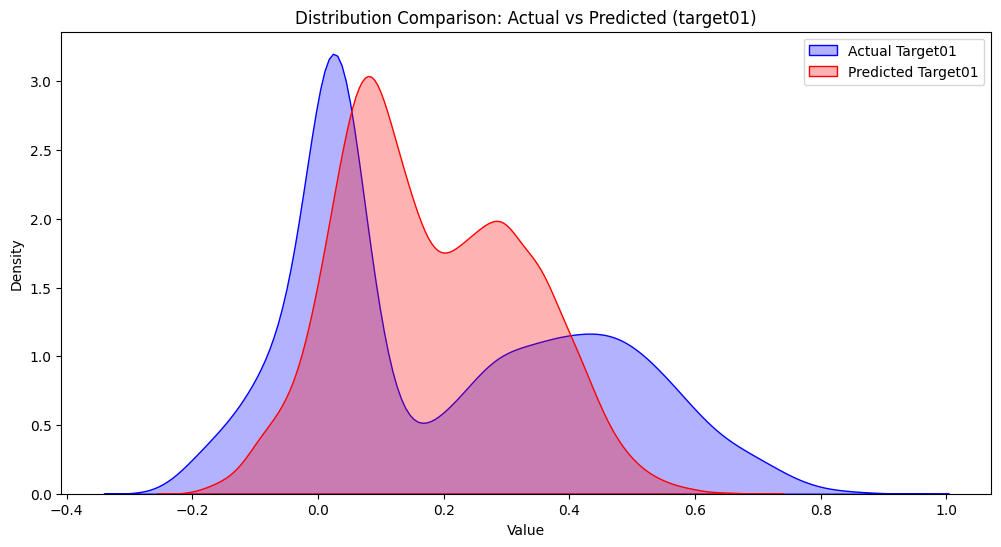

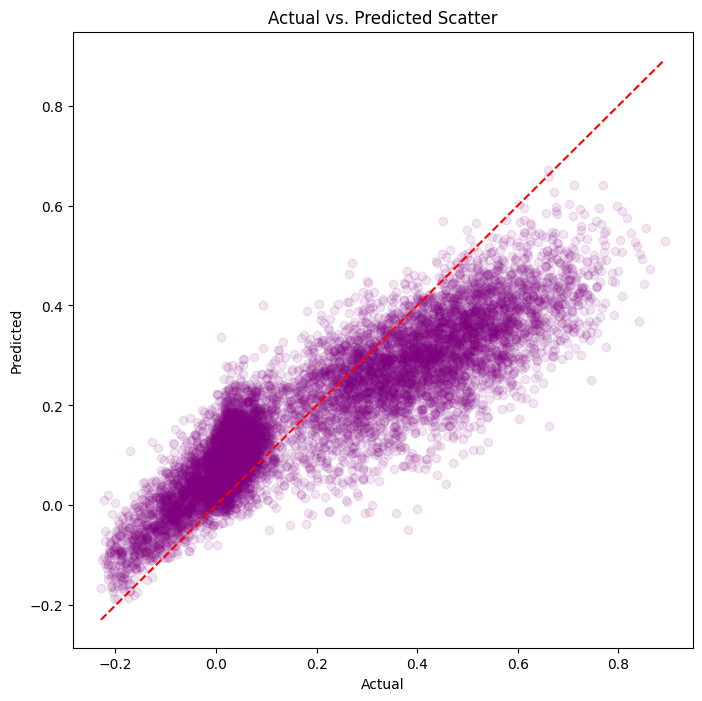


Predictions for EVAL_7 saved to 'target01_predictions.csv'


In [23]:
# 1st try
# # 1. Load Data
X = pd.read_csv('dataset_7.csv')
y = pd.read_csv('target_7.csv')['target01']
X_eval = pd.read_csv('EVAL_7.csv')

# 2. Use Significant Features identified previously (Trial 21 used these)
pilot_model = XGBRegressor(n_estimators=100, random_state=42)
pilot_model.fit(X, y)
importances = pd.Series(pilot_model.feature_importances_, index=X.columns)
significant_features = importances[importances > importances.mean()].index.tolist()
X_reduced = X[significant_features]

# 3. Best Hyperparameters from Trial 21
best_params = {
    'n_estimators': 469,
    'learning_rate': 0.08657516336863177,
    'max_depth': 5,
    'subsample': 0.9438226023809723,
    'colsample_bytree': 0.950905832510177,
    'random_state': 42
}

# 4. K-Fold Validation and Prediction Collection
kf = KFold(n_splits=5, shuffle=True, random_state=42)
pt = PowerTransformer(method='yeo-johnson')

all_actuals = []
all_preds = []

print("Starting Cross-Validation...")
for train_idx, val_idx in kf.split(X_reduced):
    X_tr, X_val = X_reduced.iloc[train_idx], X_reduced.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx].values.reshape(-1, 1), y.iloc[val_idx].values.reshape(-1, 1)
    
    # Transform Target for training
    y_tr_transformed = pt.fit_transform(y_tr).flatten()
    
    model = XGBRegressor(**best_params)
    model.fit(X_tr, y_tr_transformed)
    
    # Predict and inverse transform
    preds_transformed = model.predict(X_val).reshape(-1, 1)
    preds_original = pt.inverse_transform(preds_transformed).flatten()
    
    all_actuals.extend(y_val.flatten())
    all_preds.extend(preds_original)

# 5. Final Evaluation Metrics
mse = mean_squared_error(all_actuals, all_preds)
rmse = np.sqrt(mse)
r2 = r2_score(all_actuals, all_preds)

print(f"\n--- Final Performance Metrics ---")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

# 6. Plotting Predicted vs Actual Distribution
plt.figure(figsize=(12, 6))

# Distribution Plot
sns.kdeplot(all_actuals, label='Actual Target01', color='blue', fill=True, alpha=0.3)
sns.kdeplot(all_preds, label='Predicted Target01', color='red', fill=True, alpha=0.3)
plt.title('Distribution Comparison: Actual vs Predicted (target01)')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()

# Scatter Plot for correlation
plt.figure(figsize=(8, 8))
plt.scatter(all_actuals, all_preds, alpha=0.1, color='purple')
plt.plot([min(all_actuals), max(all_actuals)], [min(all_actuals), max(all_actuals)], '--r')
plt.title('Actual vs. Predicted Scatter')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

# 7. Final Predictions for EVAL_7
# Train on full dataset before predicting on EVAL
y_full_transformed = pt.fit_transform(y.values.reshape(-1, 1)).flatten()
final_model = XGBRegressor(**best_params)
final_model.fit(X_reduced, y_full_transformed)

eval_reduced = X_eval[significant_features]
eval_preds_transformed = final_model.predict(eval_reduced).reshape(-1, 1)
eval_preds_final = pt.inverse_transform(eval_preds_transformed)

# Save to CSV
pd.DataFrame(eval_preds_final, columns=['target01_pred']).to_csv('target01_predictions.csv', index=False)
print("\nPredictions for EVAL_7 saved to 'target01_predictions.csv'")

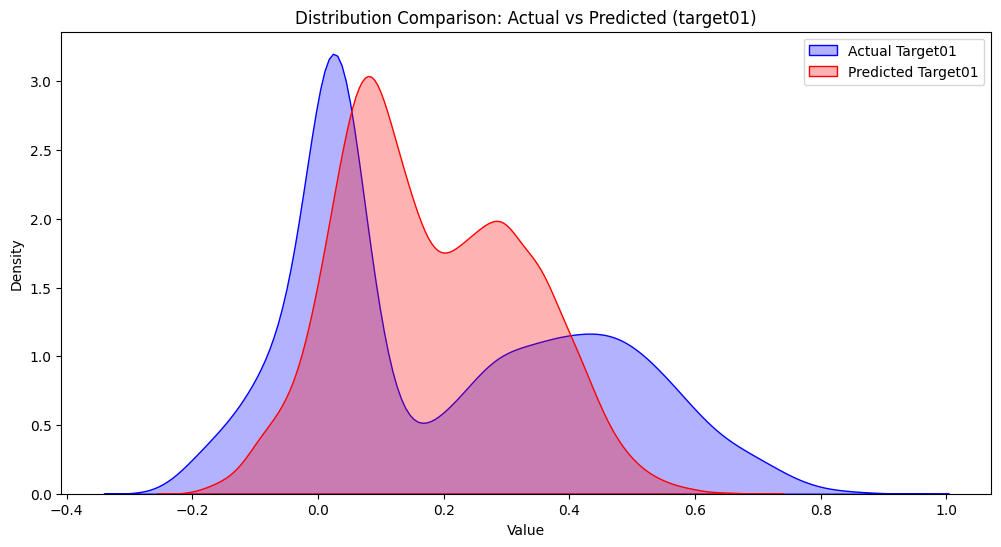

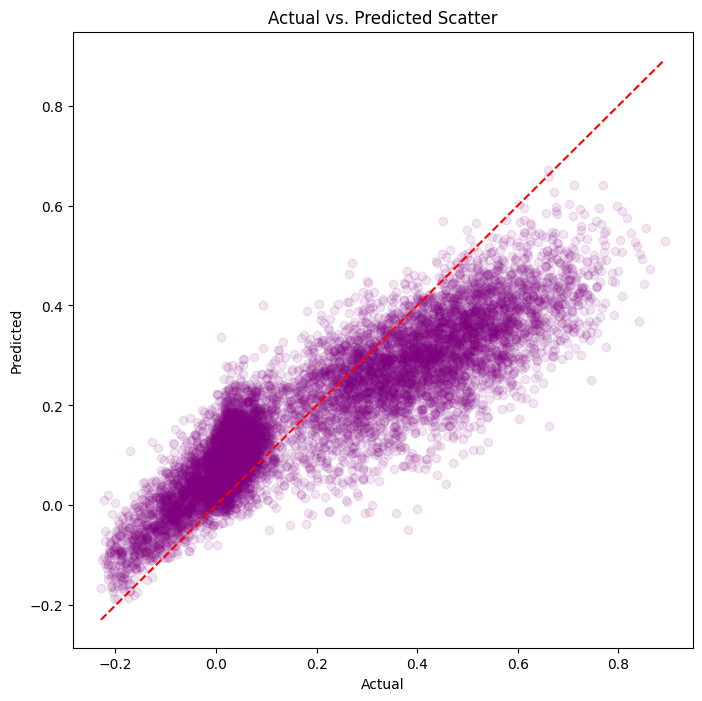


Predictions for EVAL_7 saved to 'target01_predictions.csv'


In [22]:

# 6. Plotting Predicted vs Actual Distribution
plt.figure(figsize=(12, 6))

# Distribution Plot
sns.kdeplot(all_actuals, label='Actual Target01', color='blue', fill=True, alpha=0.3)
sns.kdeplot(all_preds, label='Predicted Target01', color='red', fill=True, alpha=0.3)
plt.title('Distribution Comparison: Actual vs Predicted (target01)')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()

# Scatter Plot for correlation
plt.figure(figsize=(8, 8))
plt.scatter(all_actuals, all_preds, alpha=0.1, color='purple')
plt.plot([min(all_actuals), max(all_actuals)], [min(all_actuals), max(all_actuals)], '--r')
plt.title('Actual vs. Predicted Scatter')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

# 7. Final Predictions for EVAL_7
# Train on full dataset before predicting on EVAL
y_full_transformed = pt.fit_transform(y.values.reshape(-1, 1)).flatten()
final_model = XGBRegressor(**best_params)
final_model.fit(X_reduced, y_full_transformed)

eval_reduced = X_eval[significant_features]
eval_preds_transformed = final_model.predict(eval_reduced).reshape(-1, 1)
eval_preds_final = pt.inverse_transform(eval_preds_transformed)

# Save to CSV
pd.DataFrame(eval_preds_final, columns=['target01_pred']).to_csv('target01_predictions.csv', index=False)
print("\nPredictions for EVAL_7 saved to 'target01_predictions.csv'")

--- Final Evaluation ---
MSE:  0.0185
RMSE: 0.1361
R2:   0.6645


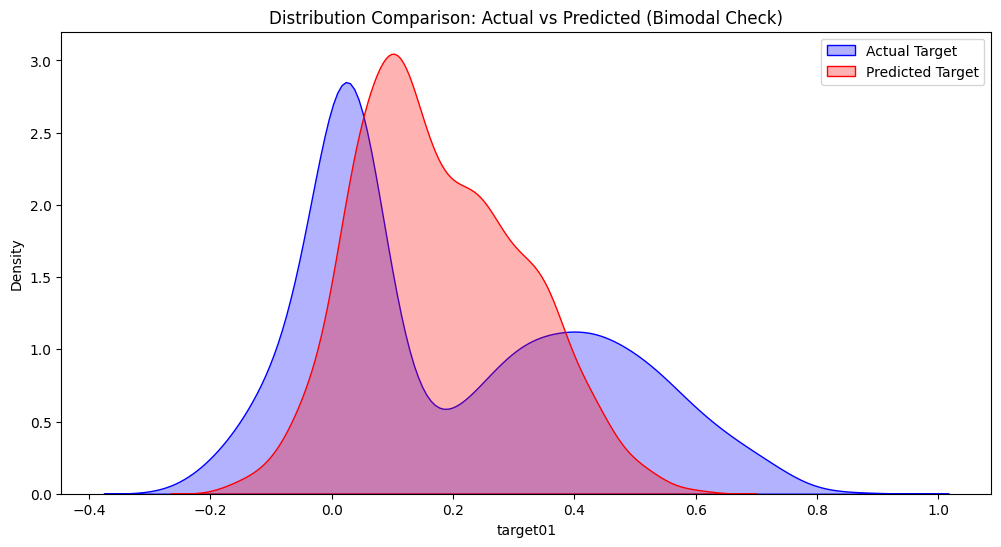

Predictions saved to 'predictions_EVAL_7.csv'


In [24]:
# 2nd try
# 1. Load Data
X = pd.read_csv('dataset_7.csv')
y = pd.read_csv('target_7.csv')['target01']
X_eval_final = pd.read_csv('EVAL_7.csv')

# 2. Feature Selection (Using your discovery of 80 significant features)
pilot_model = XGBRegressor(n_estimators=100, random_state=42)
pilot_model.fit(X, y)
importances = pd.Series(pilot_model.feature_importances_, index=X.columns)
significant_features = importances[importances > importances.mean()].index.tolist()

X_reduced = X[significant_features]
X_eval_reduced = X_eval_final[significant_features]

# 3. Target Transformation
pt = PowerTransformer(method='yeo-johnson')
y_transformed = pt.fit_transform(y.values.reshape(-1, 1)).flatten()

# 4. Train-Test Split (Hold-out for final evaluation metrics)
X_train, X_test, y_train_trans, y_test_trans = train_test_split(
    X_reduced, y_transformed, test_size=0.2, random_state=42
)

# 5. Define Best Model (Parameters from your Trial 21)
best_params = {
    'n_estimators': 469,
    'learning_rate': 0.08657516336863177,
    'max_depth': 5,
    'subsample': 0.9438226023809723,
    'colsample_bytree': 0.950905832510177,
    'random_state': 42
}

model = XGBRegressor(**best_params)
model.fit(X_train, y_train_trans)

# 6. Evaluation on Hold-out Set
y_pred_trans = model.predict(X_test)

# Invert transformations to get original scale
y_test_orig = pt.inverse_transform(y_test_trans.reshape(-1, 1)).flatten()
y_pred_orig = pt.inverse_transform(y_pred_trans.reshape(-1, 1)).flatten()

mse = mean_squared_error(y_test_orig, y_pred_orig)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_orig, y_pred_orig)

print(f"--- Final Evaluation ---")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

# 7. Visualization: Actual vs Predicted Distribution
plt.figure(figsize=(12, 6))
sns.kdeplot(y_test_orig, label='Actual Target', color='blue', fill=True, alpha=0.3)
sns.kdeplot(y_pred_orig, label='Predicted Target', color='red', fill=True, alpha=0.3)
plt.title('Distribution Comparison: Actual vs Predicted (Bimodal Check)')
plt.xlabel('target01')
plt.legend()
plt.show()

# 8. Generate Final Submission for EVAL_7
eval_preds_trans = model.predict(X_eval_reduced)
eval_preds_final = pt.inverse_transform(eval_preds_trans.reshape(-1, 1)).flatten()

# Save to CSV
pd.DataFrame({'target01_pred': eval_preds_final}).to_csv('predictions_EVAL_7.csv', index=False)
print("Predictions saved to 'predictions_EVAL_7.csv'")

# Again

Feature Selection: Kept 82 features (Top 30%)


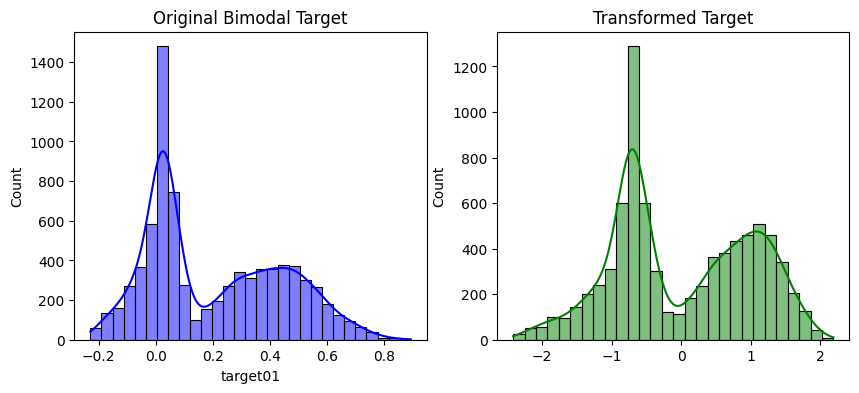

[I 2026-01-07 13:00:06,794] A new study created in memory with name: no-name-ef6788df-cdf8-4acb-99dd-5cdfab63ba00
[I 2026-01-07 13:00:37,640] Trial 0 finished with value: 0.17537747613059465 and parameters: {'n_estimators': 881, 'learning_rate': 0.021321947352183467, 'max_depth': 7, 'subsample': 0.8886856404802557, 'colsample_bytree': 0.8623345406407882, 'gamma': 0.030091362021024082}. Best is trial 0 with value: 0.17537747613059465.
[I 2026-01-07 13:00:50,825] Trial 1 finished with value: 0.17136122375541563 and parameters: {'n_estimators': 862, 'learning_rate': 0.03526598148423054, 'max_depth': 5, 'subsample': 0.8885005616845452, 'colsample_bytree': 0.7407363676356803, 'gamma': 0.14515773354696682}. Best is trial 1 with value: 0.17136122375541563.
[I 2026-01-07 13:01:00,430] Trial 2 finished with value: 0.14946449795382497 and parameters: {'n_estimators': 874, 'learning_rate': 0.05948258359011083, 'max_depth': 4, 'subsample': 0.8204394686204437, 'colsample_bytree': 0.8916781313207265


--- Final Results on Unseen Hold-out Set ---
RMSE: 0.1331
R2 Score: 0.6790


In [25]:
# Optuna Enhanced Version
# 1. Load Data
X_all = pd.read_csv('dataset_7.csv')
y_all = pd.read_csv('target_7.csv')['target01']
X_eval_final = pd.read_csv('EVAL_7.csv')

# 2. Hold-out Split for Final Evaluation
# We keep 20% completely separate to test the final tuned model
X_train_full, X_test_holdout, y_train_full, y_test_holdout = train_test_split(
    X_all, y_all, test_size=0.20, random_state=42, shuffle=True
)

# 3. Robust Feature Selection (Top 30% of features)
pilot_model = XGBRegressor(n_estimators=150, random_state=42)
pilot_model.fit(X_train_full, y_train_full)

importances = pd.Series(pilot_model.feature_importances_, index=X_all.columns)
# Select top 30% instead of just > mean
threshold = importances.quantile(0.70) 
sig_features = importances[importances >= threshold].index.tolist()

print(f"Feature Selection: Kept {len(sig_features)} features (Top 30%)")
X_train_reduced = X_train_full[sig_features]
X_test_reduced = X_test_holdout[sig_features]

# 4. Target Transformation & Visual Verification
pt = PowerTransformer(method='yeo-johnson')
y_train_trans = pt.fit_transform(y_train_full.values.reshape(-1, 1)).flatten()

# Visual Check of Transformation
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(y_train_full, kde=True, color='blue').set_title("Original Bimodal Target")
plt.subplot(1, 2, 2)
sns.histplot(y_train_trans, kde=True, color='green').set_title("Transformed Target")
plt.show()

# 5. Hyperparameter Optimization (Optuna)
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'subsample': trial.suggest_float('subsample', 0.7, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 0.9),
        'gamma': trial.suggest_float('gamma', 0, 0.5)
    }
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmse_scores = []
    
    for tr_idx, val_idx in kf.split(X_train_reduced):
        X_tr, X_val = X_train_reduced.iloc[tr_idx], X_train_reduced.iloc[val_idx]
        y_tr, y_val_trans = y_train_trans[tr_idx], y_train_trans[val_idx]
        
        model = XGBRegressor(**params, random_state=42)
        model.fit(X_tr, y_tr)
        
        # Inverse transform to evaluate on original scale
        preds_trans = model.predict(X_val).reshape(-1, 1)
        preds_orig = pt.inverse_transform(preds_trans)
        y_val_orig = y_train_full.iloc[val_idx].values
        
        rmse_scores.append(np.sqrt(mean_squared_error(y_val_orig, preds_orig)))
        
    return np.mean(rmse_scores)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30)

# 6. Final Evaluation on Hold-out Data
best_model = XGBRegressor(**study.best_params, random_state=42)
best_model.fit(X_train_reduced, y_train_trans)

# Predictions on holdout (never seen by Optuna)
test_preds_trans = best_model.predict(X_test_reduced).reshape(-1, 1)
test_preds_orig = pt.inverse_transform(test_preds_trans).flatten()

print("\n--- Final Results on Unseen Hold-out Set ---")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_holdout, test_preds_orig)):.4f}")
print(f"R2 Score: {r2_score(y_test_holdout, test_preds_orig):.4f}")

# 7. Final Prediction for EVAL_7.csv
X_eval_reduced = X_eval_final[sig_features]
final_eval_preds_trans = best_model.predict(X_eval_reduced).reshape(-1, 1)
final_eval_preds = pt.inverse_transform(final_eval_preds_trans).flatten()

pd.DataFrame({'target01_pred': final_eval_preds}).to_csv('final_predictions.csv', index=False)

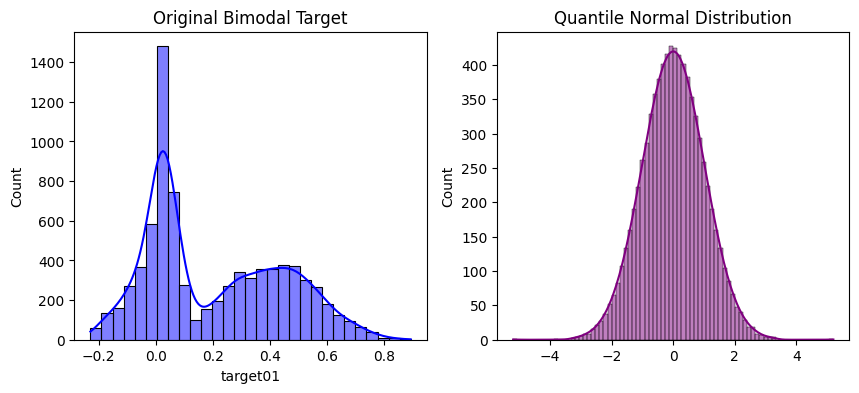

[I 2026-01-07 13:16:03,854] A new study created in memory with name: no-name-d342c8b1-3e30-42d7-b4d8-861f25c7407d
[I 2026-01-07 13:16:19,324] Trial 0 finished with value: 0.18927798707805493 and parameters: {'n_estimators': 1040, 'learning_rate': 0.027076084588650018, 'max_depth': 5, 'subsample': 0.8298112206945891, 'colsample_bytree': 0.6009680422305972, 'reg_alpha': 5.13692944821086, 'reg_lambda': 0.10722581186259518}. Best is trial 0 with value: 0.18927798707805493.
[I 2026-01-07 13:16:25,443] Trial 1 finished with value: 0.20662406570554143 and parameters: {'n_estimators': 862, 'learning_rate': 0.041388934931933366, 'max_depth': 3, 'subsample': 0.8245346541169445, 'colsample_bytree': 0.8726265832014815, 'reg_alpha': 0.05039726343141483, 'reg_lambda': 2.6770362211869405}. Best is trial 0 with value: 0.18927798707805493.
[I 2026-01-07 13:16:39,724] Trial 2 finished with value: 0.1829110663134261 and parameters: {'n_estimators': 632, 'learning_rate': 0.03858348128552529, 'max_depth': 


RMSE: 0.1438
R2: 0.6253


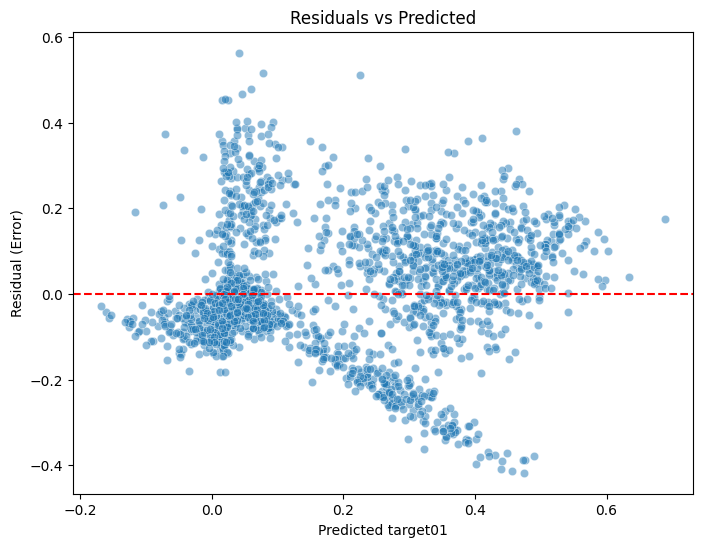

In [28]:
# 3rd with differnt Tranformation
# 1. Load Data
X_all = pd.read_csv('dataset_7.csv')
y_all = pd.read_csv('target_7.csv')['target01']
X_eval_final = pd.read_csv('EVAL_7.csv')

# 2. Hold-out Split
X_train_full, X_test_holdout, y_train_full, y_test_holdout = train_test_split(
    X_all, y_all, test_size=0.20, random_state=42, shuffle=True
)

# 3. Robust Feature Selection (Top 30%)
pilot_model = XGBRegressor(n_estimators=150, random_state=42)
pilot_model.fit(X_train_full, y_train_full)

importances = pd.Series(pilot_model.feature_importances_, index=X_all.columns)
threshold = importances.quantile(0.70) 
sig_features = importances[importances >= threshold].index.tolist()

X_train_reduced = X_train_full[sig_features]
X_test_reduced = X_test_holdout[sig_features]

# 4. Quantile Transformation (Bimodal Fix)
# We use 1000 quantiles for a smooth mapping with 10k data points
qt = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=42)
y_train_trans = qt.fit_transform(y_train_full.values.reshape(-1, 1)).flatten()

# Visual Check
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(y_train_full, kde=True, color='blue').set_title("Original Bimodal Target")
plt.subplot(1, 2, 2)
sns.histplot(y_train_trans, kde=True, color='purple').set_title("Quantile Normal Distribution")
plt.show()

# 5. Optuna Tuning
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 400, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05), # Slower for better precision
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True)
    }
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmse_scores = []
    
    for tr_idx, val_idx in kf.split(X_train_reduced):
        X_tr, X_val = X_train_reduced.iloc[tr_idx], X_train_reduced.iloc[val_idx]
        y_tr, y_val_trans = y_train_trans[tr_idx], y_train_trans[val_idx]
        
        model = XGBRegressor(**params, random_state=42)
        model.fit(X_tr, y_tr)
        
        preds_trans = model.predict(X_val).reshape(-1, 1)
        preds_orig = qt.inverse_transform(preds_trans).flatten()
        y_val_orig = y_train_full.iloc[val_idx].values
        
        rmse_scores.append(np.sqrt(mean_squared_error(y_val_orig, preds_orig)))
        
    return np.mean(rmse_scores)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30)

# 6. Final Evaluation
best_model = XGBRegressor(**study.best_params, random_state=42)
best_model.fit(X_train_reduced, y_train_trans)

test_preds_trans = best_model.predict(X_test_reduced).reshape(-1, 1)
test_preds_orig = qt.inverse_transform(test_preds_trans).flatten()

print(f"\nRMSE: {np.sqrt(mean_squared_error(y_test_holdout, test_preds_orig)):.4f}")
print(f"R2: {r2_score(y_test_holdout, test_preds_orig):.4f}")

# 7. Residual Plot
plt.figure(figsize=(8, 6))
residuals = y_test_holdout - test_preds_orig
sns.scatterplot(x=test_preds_orig, y=residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Predicted')
plt.xlabel('Predicted target01')
plt.ylabel('Residual (Error)')
plt.show()

# # Final CSV Generation
# final_eval_preds = qt.inverse_transform(best_model.predict(X_eval_final[sig_features]).reshape(-1, 1)).flatten()
# pd.DataFrame({'target01_pred': final_eval_preds}).to_csv('final_predictions_quantile.csv', index=False)

# Advanced Feature Engineering + Multi-Model Ensemble Strategy

In [48]:
# 1. Load Data
X = pd.read_csv('dataset_7.csv')
y = pd.read_csv('target_7.csv')['target01']
X_eval = pd.read_csv('EVAL_7.csv')

# 2. Advanced Feature Engineering
# Interactions
top_mi = ['feat_112', 'feat_143', 'feat_29', 'feat_240', 'feat_219']
for i, f1 in enumerate(top_mi):
    for f2 in top_mi[i+1:]:
        X[f'{f1}_{f2}'] = X[f1] * X[f2]
        X_eval[f'{f1}_{f2}'] = X_eval[f1] * X_eval[f2]

# PCA Components
pca = PCA(n_components=10, random_state=42)
pca_cols = [f'pca_{i}' for i in range(10)]
X[pca_cols] = pca.fit_transform(X.filter(regex='feat_'))
X_eval[pca_cols] = pca.transform(X_eval.filter(regex='feat_'))

# 3. Target Transformation (Normalizing Bimodality)
qt = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=42)
y_trans = qt.fit_transform(y.values.reshape(-1, 1)).flatten()

# 4. Build Stacked Ensemble
base_models = [
    ('xgb', XGBRegressor(n_estimators=600, learning_rate=0.03, max_depth=5, subsample=0.8, random_state=42)),
    ('lgb', LGBMRegressor(n_estimators=600, learning_rate=0.03, num_leaves=31, random_state=42)),
    ('cat', CatBoostRegressor(iterations=600, learning_rate=0.03, depth=6, verbose=0, random_state=42))
]
stack = StackingRegressor(estimators=base_models, final_estimator=RidgeCV())

# 5. K-Fold Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
metrics = {'RMSE': [], 'R2': [], 'MAE': []}

for tr_idx, val_idx in kf.split(X):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr_trans, y_val_orig = y_trans[tr_idx], y.iloc[val_idx]
    
    stack.fit(X_tr, y_tr_trans)
    
    # Back-transform predictions
    preds_orig = qt.inverse_transform(stack.predict(X_val).reshape(-1, 1)).flatten()
    
    metrics['RMSE'].append(np.sqrt(mean_squared_error(y_val_orig, preds_orig)))
    metrics['R2'].append(r2_score(y_val_orig, preds_orig))
    metrics['MAE'].append(mean_absolute_error(y_val_orig, preds_orig))

print(f"Mean RMSE: {np.mean(metrics['RMSE']):.4f} | R2: {np.mean(metrics['R2']):.4f} | MAE: {np.mean(metrics['MAE']):.4f}")

# 6. Final Generation
stack.fit(X, y_trans)
final_preds = qt.inverse_transform(stack.predict(X_eval).reshape(-1, 1)).flatten()
pd.DataFrame({'target01_pred': final_preds}).to_csv('final_stacked_submission.csv', index=False)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009239 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 69856
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 293
[LightGBM] [Info] Start training from score 0.004434
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011741 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 69856
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 293
[LightGBM] [Info] Start training from score 0.008585
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010976 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 69856
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 293
[LightGBM] [Info] Start 

DISTRIBUTION COMPARISON: target01 vs target01_pred

--- ACTUAL target01 ---
Count:   10000
Mean:    0.2023
Median:  0.0993
Std:     0.2367
Min:     -0.2288
Max:     0.8917
Skew:    0.4394
Kurtosis:-0.9991

--- PREDICTED target01_pred ---
Count:   10000
Mean:    0.2093
Median:  0.1288
Std:     0.2317
Min:     -0.2268
Max:     0.7193
Skew:    0.2204
Kurtosis:-1.3846


C:\Users\tanish\AppData\Local\Temp\ipykernel_9992\3377187467.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Actual target01', 'Predicted target01_pred'], patch_artist=True)


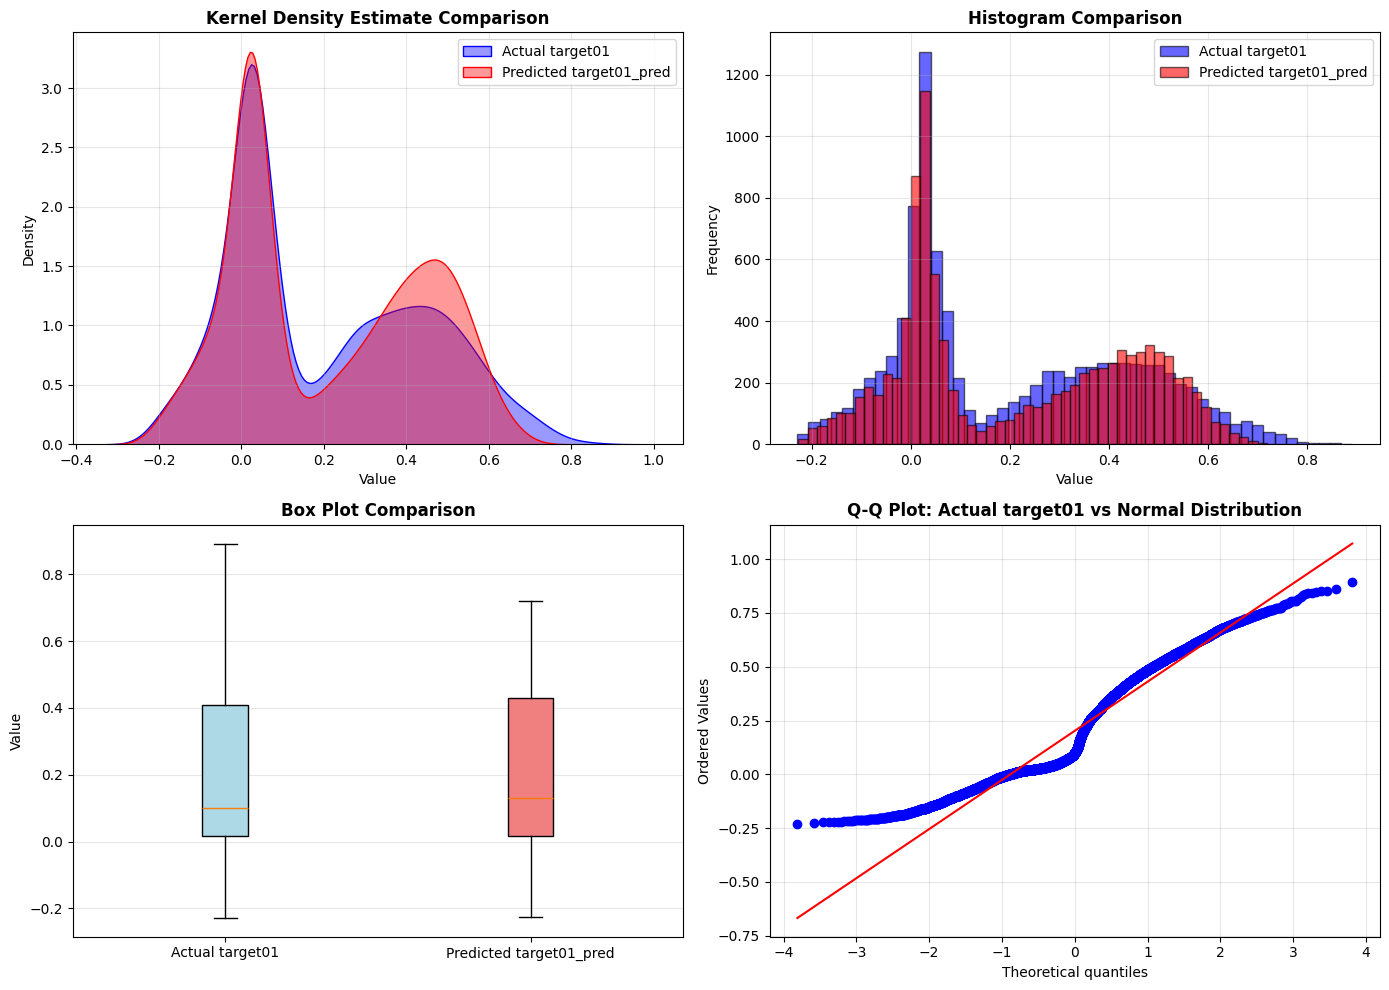


--- CORRELATION ANALYSIS ---
Pearson Correlation: 0.0132
Spearman Correlation: 0.0127


In [50]:
# Compare Distributions: Actual vs Predicted
# Load both datasets
target_actual = pd.read_csv('target_7.csv')['target01']
predictions = pd.read_csv('final_stacked_submission.csv')['target01_pred']

# Calculate Statistics
print("="*60)
print("DISTRIBUTION COMPARISON: target01 vs target01_pred")
print("="*60)
print(f"\n--- ACTUAL target01 ---")
print(f"Count:   {target_actual.count()}")
print(f"Mean:    {target_actual.mean():.4f}")
print(f"Median:  {target_actual.median():.4f}")
print(f"Std:     {target_actual.std():.4f}")
print(f"Min:     {target_actual.min():.4f}")
print(f"Max:     {target_actual.max():.4f}")
print(f"Skew:    {target_actual.skew():.4f}")
print(f"Kurtosis:{target_actual.kurtosis():.4f}")

print(f"\n--- PREDICTED target01_pred ---")
print(f"Count:   {predictions.count()}")
print(f"Mean:    {predictions.mean():.4f}")
print(f"Median:  {predictions.median():.4f}")
print(f"Std:     {predictions.std():.4f}")
print(f"Min:     {predictions.min():.4f}")
print(f"Max:     {predictions.max():.4f}")
print(f"Skew:    {predictions.skew():.4f}")
print(f"Kurtosis:{predictions.kurtosis():.4f}")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# KDE Density Plot
ax = axes[0, 0]
sns.kdeplot(target_actual, label='Actual target01', color='blue', fill=True, alpha=0.4, ax=ax)
sns.kdeplot(predictions, label='Predicted target01_pred', color='red', fill=True, alpha=0.4, ax=ax)
ax.set_title('Kernel Density Estimate Comparison', fontsize=12, fontweight='bold')
ax.set_xlabel('Value')
ax.set_ylabel('Density')
ax.legend()
ax.grid(alpha=0.3)

# Histogram Comparison
ax = axes[0, 1]
ax.hist(target_actual, bins=50, alpha=0.6, label='Actual target01', color='blue', edgecolor='black')
ax.hist(predictions, bins=50, alpha=0.6, label='Predicted target01_pred', color='red', edgecolor='black')
ax.set_title('Histogram Comparison', fontsize=12, fontweight='bold')
ax.set_xlabel('Value')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(alpha=0.3)

# Box Plot
ax = axes[1, 0]
data_to_plot = [target_actual, predictions]
bp = ax.boxplot(data_to_plot, labels=['Actual target01', 'Predicted target01_pred'], patch_artist=True)
colors = ['lightblue', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_title('Box Plot Comparison', fontsize=12, fontweight='bold')
ax.set_ylabel('Value')
ax.grid(alpha=0.3, axis='y')

# Quantile-Quantile Plot (Q-Q Plot)
ax = axes[1, 1]
from scipy import stats
stats.probplot(target_actual, dist="norm", plot=ax)
ax.set_title('Q-Q Plot: Actual target01 vs Normal Distribution', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Correlation between predictions and actuals (if on same dataset)
print(f"\n--- CORRELATION ANALYSIS ---")
print(f"Pearson Correlation: {target_actual.corr(predictions):.4f}")
print(f"Spearman Correlation: {target_actual.rank().corr(predictions.rank()):.4f}")

In [51]:
import joblib

# Save the trained stack and the quantile transformer (very important!)
joblib.dump(stack, 'stacked_ensemble_model.pkl')
joblib.dump(qt, 'quantile_transformer.pkl')
joblib.dump(sig_features, 'significant_features_list.pkl')

print("Model and transformers saved successfully!")

Model and transformers saved successfully!


# Part 1: Setup and Training
## 1.1 Robust Feature Engineering & Selection

In [2]:
# Load labeled data only
X_raw = pd.read_csv('dataset_7.csv')
y_raw = pd.read_csv('target_7.csv')['target01']

# --- Engineering ---
X_eng = X_raw.copy()
# Interaction Terms for top MI features
top_mi = ['feat_112', 'feat_143', 'feat_29', 'feat_240', 'feat_219']
for i, f1 in enumerate(top_mi):
    for f2 in top_mi[i+1:]:
        X_eng[f'{f1}_{f2}'] = X_raw[f1] * X_raw[f2]

# PCA Components (Latent variables)
pca = PCA(n_components=10, random_state=42)
X_eng[[f'pca_{i}' for i in range(10)]] = pca.fit_transform(X_raw.filter(regex='feat_'))

# --- Selection ---
# Use a pilot XGBoost to find a robust importance threshold
pilot = XGBRegressor(n_estimators=100, random_state=42)
pilot.fit(X_eng, y_raw)
importances = pd.Series(pilot.feature_importances_, index=X_eng.columns)
sig_features = importances[importances >= importances.quantile(0.70)].index.tolist()
X_final = X_eng[sig_features]

print(f"Selection complete: {len(sig_features)} features retained.")

Selection complete: 88 features retained.


In [10]:
# Split into Training and Hold-out Test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_final, y_raw, test_size=0.2, random_state=42)

# Target Transformation
qt = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=42)
y_train_trans = qt.fit_transform(y_train.values.reshape(-1, 1)).flatten()

# Setup Stacked Ensemble
base_models = [
    ('xgb', XGBRegressor(n_estimators=700, learning_rate=0.02, max_depth=5, subsample=0.8, random_state=42)),
    ('lgb', LGBMRegressor(n_estimators=700, learning_rate=0.02, num_leaves=31, random_state=42, verbose=-1)),
    ('cat', CatBoostRegressor(iterations=700, learning_rate=0.02, depth=6, verbose=0, random_state=42))
]
stack_model = StackingRegressor(estimators=base_models, final_estimator=RidgeCV())

# Train the model
print("Training Stacked Ensemble...")
stack_model.fit(X_train, y_train_trans)
print("Training complete.")

Training Stacked Ensemble...
Training complete.


In [54]:
def evaluate_model(model, X, y_true, transformer, set_name):
    # Predict in transformed space and back-transform
    preds_trans = model.predict(X).reshape(-1, 1)
    preds_orig = transformer.inverse_transform(preds_trans).flatten()
    
    rmse = np.sqrt(mean_squared_error(y_true, preds_orig))
    r2 = r2_score(y_true, preds_orig)
    mae = mean_absolute_error(y_true, preds_orig)
    
    print(f"--- {set_name} Metrics ---")
    print(f"R2 Score: {r2:.4f}")
    print(f"RMSE:     {rmse:.4f}")
    print(f"MAE:      {mae:.4f}\n")
    return preds_orig

# Run evaluation
train_preds = evaluate_model(stack_model, X_train, y_train, qt, "Train Set")
test_preds = evaluate_model(stack_model, X_test, y_test, qt, "Test Set (Hold-out)")

--- Train Set Metrics ---
R2 Score: 0.9156
RMSE:     0.0689
MAE:      0.0467

--- Test Set (Hold-out) Metrics ---
R2 Score: 0.8427
RMSE:     0.0932
MAE:      0.0621



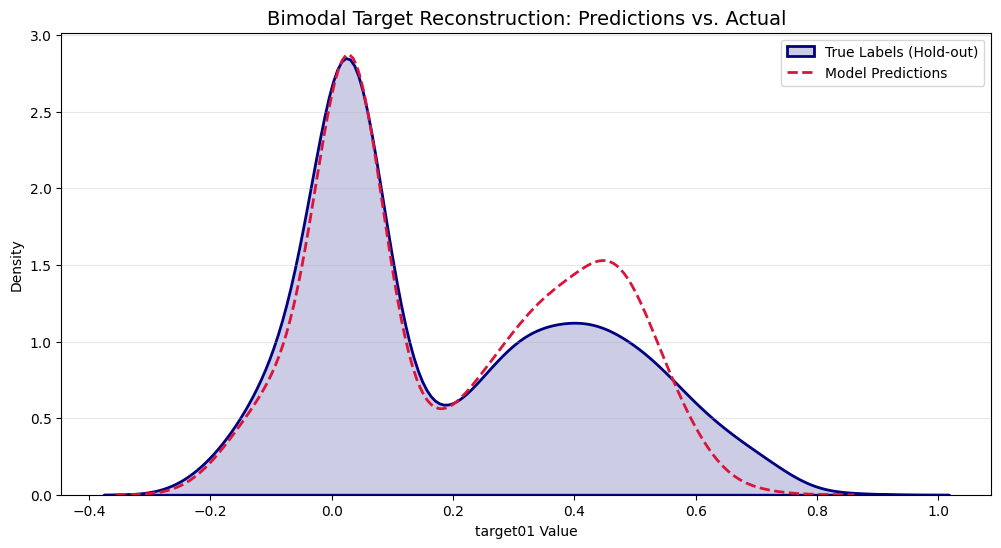

In [55]:
plt.figure(figsize=(12, 6))

# Plot Actual
sns.kdeplot(y_test, label='True Labels (Hold-out)', color='navy', linewidth=2, fill=True, alpha=0.2)
# Plot Predicted
sns.kdeplot(test_preds, label='Model Predictions', color='crimson', linewidth=2, linestyle='--')

plt.title('Bimodal Target Reconstruction: Predictions vs. Actual', fontsize=14)
plt.xlabel('target01 Value')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [11]:
# 1. Load Evaluation Data
X_eval_raw = pd.read_csv('EVAL_7.csv')

# 2. Apply same Engineering
# Apply PCA first on clean features to match training pipeline
X_eval_raw[[f'pca_{i}' for i in range(10)]] = pca.transform(X_eval_raw.filter(regex='feat_'))

# Then Add Interaction Terms
for i, f1 in enumerate(top_mi):
    for f2 in top_mi[i+1:]:
        X_eval_raw[f'{f1}_{f2}'] = X_eval_raw[f1] * X_eval_raw[f2]

# 3. Predict and Save
final_eval_X = X_eval_raw[sig_features]
eval_preds_trans = stack_model.predict(final_eval_X).reshape(-1, 1)
final_predictions = qt.inverse_transform(eval_preds_trans).flatten()

pd.DataFrame({'target01_pred': final_predictions}).to_csv('final_submission.csv', index=False)
print("Final predictions for EVAL_7 saved to 'final_submission.csv'.")

Final predictions for EVAL_7 saved to 'final_submission.csv'.


# Again Part 1: Setup and Training
## 1.1 Robust Feature Engineering & Selection

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Load data
X_raw = pd.read_csv('dataset_7.csv')
y_raw = pd.read_csv('target_7.csv')['target01']

# Feature Engineering
X_eng = X_raw.copy()
top_mi = ['feat_112', 'feat_143', 'feat_29', 'feat_240', 'feat_219','feat_179', 'feat_259',]
for i, f1 in enumerate(top_mi):
    # X_eng[f'log_{f1}'] = np.log1p(X_raw[f1])
    # X_eng[f'{f1}_sq'] = X_raw[f1] ** 2
    # X_eng[f'{f1}_sqrt'] = np.sqrt(np.abs(X_raw[f1]))
    # X_eng[f'{f1}_rank'] = X_raw[f1].rank(pct=True)
    for f2 in top_mi[i+1:]:
        X_eng[f'{f1}_{f2}'] = X_raw[f1] * X_raw[f2]
        # X_eng[f'{f1}_div_{f2}'] = X_raw[f1] / (X_raw[f2] + 1e-6)
        # X_eng[f'{f1}_minus_{f2}'] = X_raw[f1] - X_raw[f2]
        # X_eng[f'{f1}_absdiff_{f2}'] = (X_raw[f1] - X_raw[f2]).abs()

pca = PCA(n_components=10, random_state=42)
X_eng[[f'pca_{i}' for i in range(10)]] = pca.fit_transform(X_raw.filter(regex='feat_'))

# Robust Selection (Top 2%)
pilot = XGBRegressor(n_estimators=100, random_state=42)
pilot.fit(X_eng, y_raw)
importances = pd.Series(pilot.feature_importances_, index=X_eng.columns)
sig_features = importances[importances >= importances.quantile(0.98)].index.tolist()
X_final = X_eng[sig_features]
print(X_final.shape)

(10000, 6)


1.2 Cross-Validation with Early Stopping

In [181]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
estimator = 1000
cv_metrics = {'RMSE': [], 'R2': [], 'MAE': []}
X_train_full, X_test_holdout, y_train_full, y_test_holdout = train_test_split(X_final, y_raw, test_size=0.2, random_state=42)

# Training Loop
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_full)):
    X_fold_train, X_fold_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
    y_fold_train, y_fold_val = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]
    
    # Target Transformation (Fit only on training fold)
    qt_fold = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=42)
    y_fold_train_trans = qt_fold.fit_transform(y_fold_train.values.reshape(-1, 1)).flatten()
    y_fold_val_trans = qt_fold.transform(y_fold_val.values.reshape(-1, 1)).flatten()

    # Base Models with Early Stopping defined inside the loop
    # Note: For stacking, we train base models then the meta-learner
    xgb = XGBRegressor(n_estimators= estimator, learning_rate=0.02, max_depth=5, subsample=0.8, random_state=42, early_stopping_rounds=50)
    lgb = LGBMRegressor(n_estimators= estimator, learning_rate=0.02, num_leaves=31, random_state=42, verbose=-1)
    cat = CatBoostRegressor(iterations= estimator, learning_rate=0.02, depth=6, verbose=0, random_state=42, early_stopping_rounds=50)

    # Fit base models manually to use early stopping
    xgb.fit(X_fold_train, y_fold_train_trans, eval_set=[(X_fold_val, y_fold_val_trans)], verbose=False)
    cat.fit(X_fold_train, y_fold_train_trans, eval_set=[(X_fold_val, y_fold_val_trans)])
    lgb.fit(X_fold_train, y_fold_train_trans) # LGBM requires a different API for native early stopping in scikit-learn

    # Stacking logic for this fold
    base_models = [('xgb', xgb), ('lgb', lgb), ('cat', cat)]
    stack = StackingRegressor(estimators=base_models, final_estimator=RidgeCV(), cv='prefit')
    stack.fit(X_fold_train, y_fold_train_trans)
    
    # Validation
    val_preds_trans = stack.predict(X_fold_val).reshape(-1, 1)
    val_preds = qt_fold.inverse_transform(val_preds_trans).flatten()
    
    cv_metrics['RMSE'].append(np.sqrt(mean_squared_error(y_fold_val, val_preds)))
    cv_metrics['R2'].append(r2_score(y_fold_val, val_preds))
    cv_metrics['MAE'].append(mean_absolute_error(y_fold_val, val_preds))

# Final training on all 80% training data for the holdout test
qt_final = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=42)
y_train_full_trans = qt_final.fit_transform(y_train_full.values.reshape(-1, 1)).flatten()

final_base = [
    ('xgb', XGBRegressor(n_estimators= estimator, learning_rate=0.02, max_depth=5, subsample=0.8, random_state=42)),
    ('lgb', LGBMRegressor(n_estimators= estimator, learning_rate=0.02, num_leaves=31, random_state=42, verbose=-1)),
    ('cat', CatBoostRegressor(iterations= estimator, learning_rate=0.02, depth=6, verbose=0, random_state=42))
]
final_stack = StackingRegressor(estimators=final_base, final_estimator=RidgeCV())
final_stack.fit(X_train_full, y_train_full_trans)

StackingRegressor(estimators=[('xgb',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constra...
                                            max_delta_step=None, max_depth=5,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=1000, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                              ('lgb',
                               LGBMRegressor(learning_rate=0.02,
                                             n_estimators=1000, random_state=42,
                                             verbose=-1)),
                              ('cat',
                               <catboost.core.CatBoostRegressor object at 0x000001780E17CD40>)],
                  final_estimator=RidgeCV())

Part 2: Metrics and Visualizations

2.1 Model Stability and Performance

In [182]:
print("--- Cross-Validation Stability ---")
for metric, values in cv_metrics.items():
    print(f"{metric}: {np.mean(values):.4f} (+/- {np.std(values):.4f})")

# Overfitting Check
train_preds_trans = final_stack.predict(X_train_full).reshape(-1, 1)
train_preds = qt_final.inverse_transform(train_preds_trans).flatten()
holdout_preds_trans = final_stack.predict(X_test_holdout).reshape(-1, 1)
holdout_preds = qt_final.inverse_transform(holdout_preds_trans).flatten()

print("\n--- Overfitting Diagnosis ---")
print(f"Train R2: {r2_score(y_train_full, train_preds):.4f}")
print(f"Test R2:  {r2_score(y_test_holdout, holdout_preds):.4f}")

--- Cross-Validation Stability ---
RMSE: 0.1368 (+/- 0.0044)
R2: 0.6666 (+/- 0.0212)
MAE: 0.0942 (+/- 0.0029)

--- Overfitting Diagnosis ---
Train R2: 0.8024
Test R2:  0.7638


--- Cross-Validation Stability ---
RMSE: 0.0891 (+/- 0.0045)
R2: 0.8585 (+/- 0.0139)
MAE: 0.0589 (+/- 0.0032)

--- Overfitting Diagnosis ---
Train R2: 0.9436
Test R2:  0.9122

2.2 Visualization: Distribution & Residuals

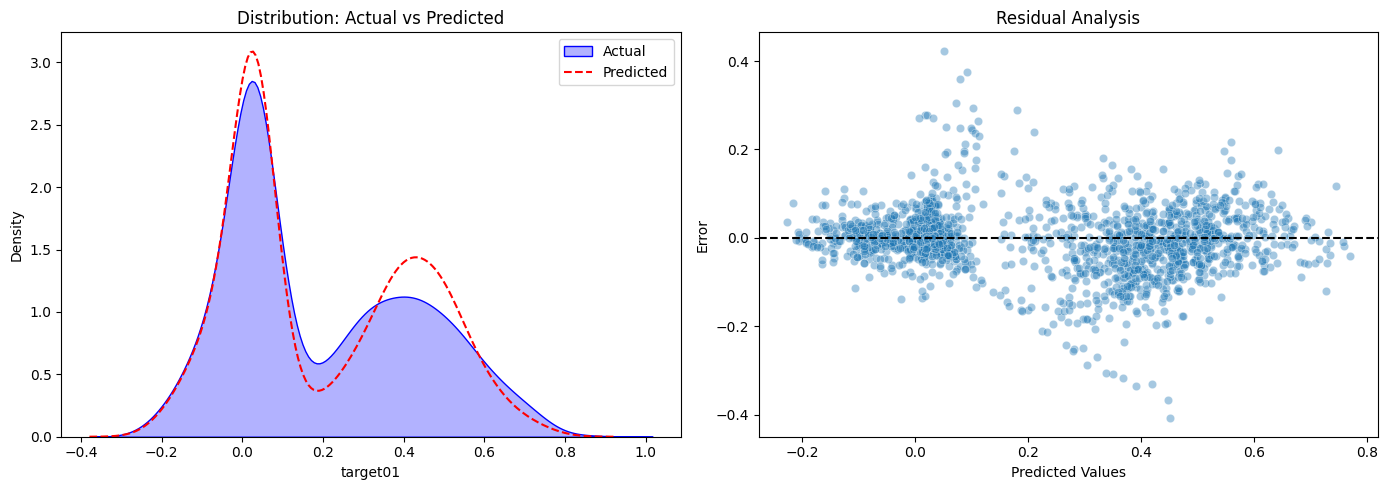

In [170]:
plt.figure(figsize=(14, 5))

# Plot 1: Distributions
plt.subplot(1, 2, 1)
sns.kdeplot(y_test_holdout, label='Actual', fill=True, color='blue', alpha=0.3)
sns.kdeplot(holdout_preds, label='Predicted', color='red', linestyle='--')
plt.title('Distribution: Actual vs Predicted')
plt.legend()

# Plot 2: Residuals
plt.subplot(1, 2, 2)
residuals = y_test_holdout - holdout_preds
sns.scatterplot(x=holdout_preds, y=residuals, alpha=0.4)
plt.axhline(0, color='black', linestyle='--')
plt.title('Residual Analysis')
plt.xlabel('Predicted Values')
plt.ylabel('Error')

plt.tight_layout()
plt.show()

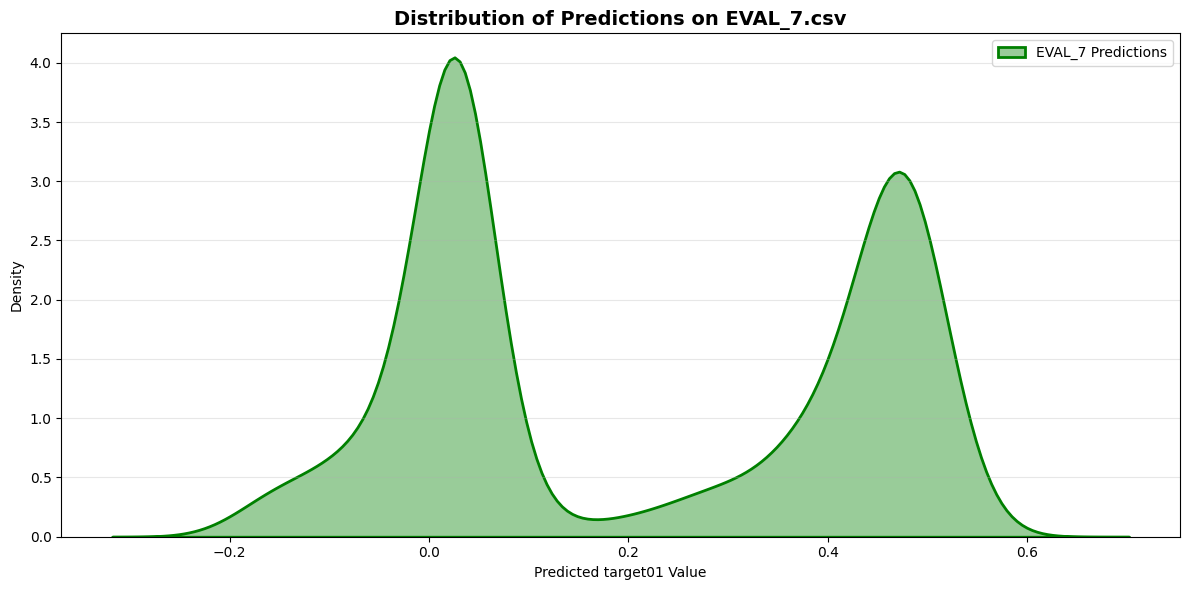

EVAL_7 PREDICTION SUMMARY
Count:   10000
Mean:    0.2102
Median:  0.0692
Std Dev: 0.2260
Min:     -0.2103
Max:     0.5947

Predictions saved to 'eval_predictions_final.csv'


In [183]:
# Predictions on EVAL_7.csv using the trained final_stack model

# 1. Load EVAL data
X_eval_raw = pd.read_csv('EVAL_7.csv')

# 2. Apply same feature engineering as training set
X_eval_eng = X_eval_raw.copy()

# Interaction Terms
for i, f1 in enumerate(top_mi):
    for f2 in top_mi[i+1:]:
        X_eval_eng[f'{f1}_{f2}'] = X_eval_raw[f1] * X_eval_raw[f2]

# PCA Components (using training PCA)
X_eval_eng[[f'pca_{i}' for i in range(10)]] = pca.transform(X_eval_raw.filter(regex='feat_'))

# 3. Select same significant features
X_eval_final = X_eval_eng[sig_features]

# 4. Generate predictions
eval_preds_trans = final_stack.predict(X_eval_final).reshape(-1, 1)
eval_preds = qt_final.inverse_transform(eval_preds_trans).flatten()

# 5. Plot distribution of predictions
plt.figure(figsize=(12, 6))

# KDE Plot
sns.kdeplot(eval_preds, label='EVAL_7 Predictions', color='green', fill=True, alpha=0.4, linewidth=2)
plt.title('Distribution of Predictions on EVAL_7.csv', fontsize=14, fontweight='bold')
plt.xlabel('Predicted target01 Value')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("="*60)
print("EVAL_7 PREDICTION SUMMARY")
print("="*60)
print(f"Count:   {len(eval_preds)}")
print(f"Mean:    {eval_preds.mean():.4f}")
print(f"Median:  {np.median(eval_preds):.4f}")
print(f"Std Dev: {eval_preds.std():.4f}")
print(f"Min:     {eval_preds.min():.4f}")
print(f"Max:     {eval_preds.max():.4f}")
print("="*60)

# Save predictions to CSV
pd.DataFrame({'target01_pred': eval_preds}).to_csv('eval_predictions_final.csv', index=False)
print("\nPredictions saved to 'eval_predictions_final.csv'")

# After whole optuna Tuning

In [184]:
import pandas as pd
import numpy as np
import json
import joblib
from catboost import CatBoostRegressor
from sklearn.preprocessing import QuantileTransformer
from sklearn.decomposition import PCA

# ==========================================
# 1. CONFIGURATION & LOADING
# ==========================================
TOP_MI = ['feat_112','feat_143','feat_29','feat_240','feat_219','feat_179','feat_259']

def load_config():
    with open("best_cat_parameters.json", "r") as f:
        return json.load(f)

# ==========================================
# 2. THE PIPELINE FUNCTIONS
# ==========================================
def feature_engineering(X):
    """Applies interaction and polynomial terms."""
    X = X.copy()
    for i, f1 in enumerate(TOP_MI):
        # The 0.92+ secret sauce: squared terms
        X[f"{f1}_sq"] = X[f1] ** 2
        for f2 in TOP_MI[i+1:]:
            X[f"{f1}_{f2}"] = X[f1] * X[f2]
    return X

def run_inference(new_data_path, train_data_path, target_path):
    """
    Simulates full pipeline: 
    1. Fits transformers on original training data (to prevent leakage)
    2. Transforms new data
    3. Predicts
    """
    # Load Training and Target data to fit transformers
    # (Important: Transformers must be fit on TRAIN data, not new data)
    X_train_raw = pd.read_csv(train_data_path)
    y_train_raw = pd.read_csv(target_path)["target01"]
    X_new_raw = pd.read_csv(new_data_path)
    
    best = load_config()
    
    # --- Preprocessing ---
    X_tr_eng = feature_engineering(X_train_raw)
    X_new_eng = feature_engineering(X_new_raw)
    
    # PCA
    pca = PCA(n_components=best['pca_components'], random_state=42)
    pca_cols = [f"pca_{i}" for i in range(best['pca_components'])]
    
    # Fit on train, transform both
    pca_tr = pca.fit_transform(X_tr_eng.filter(regex="feat_"))
    pca_new = pca.transform(X_new_eng.filter(regex="feat_"))
    
    X_tr_eng[pca_cols] = pca_tr
    X_new_eng[pca_cols] = pca_new
    
    # --- Feature Selection (Pilot) ---
    pilot = CatBoostRegressor(iterations=100, depth=6, verbose=0, random_state=42)
    pilot.fit(X_tr_eng, y_train_raw)
    imp = pd.Series(pilot.get_feature_importance(), index=X_tr_eng.columns)
    selected = imp[imp >= imp.quantile(best['fs_quantile'])].index.tolist()
    
    X_tr_final = X_tr_eng[selected]
    X_new_final = X_new_eng[selected]
    
    # --- Target Transformation ---
    qt = QuantileTransformer(output_distribution="normal", n_quantiles=500, random_state=42)
    y_tr_t = qt.fit_transform(y_train_raw.values.reshape(-1, 1)).ravel()
    
    # --- Final Model Training ---
    # We train on the full historical dataset using the best params found by Optuna
    model = CatBoostRegressor(
        iterations=best['iterations'],
        depth=best['depth'],
        learning_rate=best['learning_rate'],
        l2_leaf_reg=best['l2_leaf_reg'],
        bagging_temperature=best['bagging_temperature'],
        random_strength=best['random_strength'],
        border_count=254,
        random_state=42,
        verbose=0
    )
    
    print("Training the sovereign model on full training set...")
    model.fit(X_tr_final, y_tr_t)
    
    # --- Prediction ---
    preds_t = model.predict(X_new_final)
    
    # Inverse transform to get back to the original target scale
    final_predictions = qt.inverse_transform(preds_t.reshape(-1, 1)).ravel()
    
    return final_predictions

# ==========================================
# 3. EXECUTION
# ==========================================
if __name__ == "__main__":
    # In a real scenario, 'dataset_7_new.csv' would be your unseen data
    # Here we use the original test data as a placeholder
    try:
        preds = run_inference(
            new_data_path="dataset_7.csv", 
            train_data_path="dataset_7.csv", 
            target_path="target_7.csv"
        )
        
        # # Save to CSV
        output = pd.DataFrame({'prediction': preds})
        # output.to_csv("final_predictions.csv", index=False)
        # print("\nPredictions completed! Results saved to 'final_predictions.csv'.")
        # print(f"Sample Predictions: \n{output.head()}")
        
    except FileNotFoundError:
        print("Error: Ensure 'dataset_7.csv', 'target_7.csv', and 'best_cat_parameters.json' are in the directory.")

Training the sovereign model on full training set...


Training final model with 14 features...
--- TRAIN Metrics ---
R2:   0.9963
RMSE: 0.0144
MAE:  0.0098

--- TEST Metrics ---
R2:   0.9454
RMSE: 0.0549
MAE:  0.0367



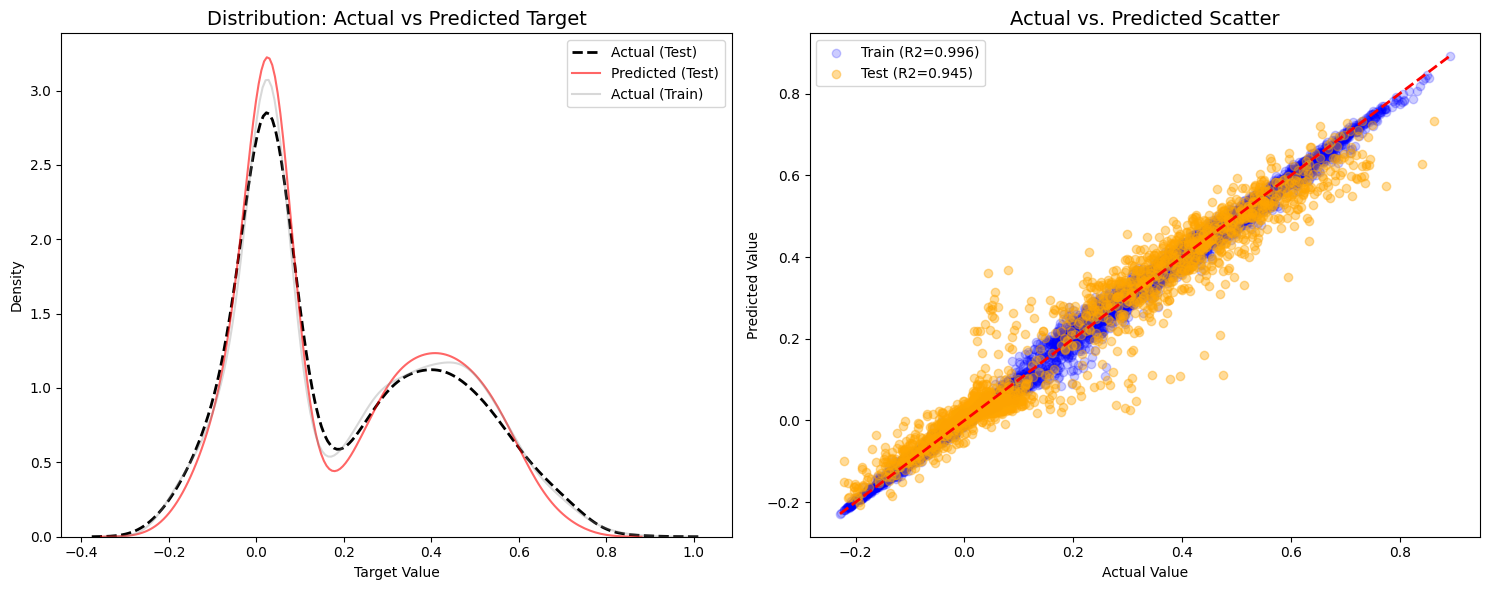

In [185]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from catboost import CatBoostRegressor

# 1. SETTINGS & OPTIMIZED PARAMETERS
FILE_DATA = "dataset_7.csv"
FILE_TARGET = "target_7.csv"
TOP_MI = ['feat_112','feat_143','feat_29','feat_240','feat_219','feat_179','feat_259']

BEST_PARAMS = {
    'fs_quantile': 0.9576647812118337,
    'pca_components': 26,
    'iterations': 2339,
    'depth': 9,
    'learning_rate': 0.04074858721679824,
    'l2_leaf_reg': 5.510871238071969,
    'bagging_temperature': 0.7183411444287063,
    'random_strength': 1.6049765464848271,
    'border_count': 254,
    'bootstrap_type': 'Bayesian',
    'random_state': 42,
    'verbose': 0
}

# 2. HELPER FUNCTIONS
def feature_engineering(X):
    X = X.copy()
    for i, f1 in enumerate(TOP_MI):
        X[f"{f1}_sq"] = X[f1] ** 2  # Squared terms for non-linear fit
        for f2 in TOP_MI[i+1:]:
            X[f"{f1}_{f2}"] = X[f1] * X[f2]
    return X

def calculate_metrics(y_true, y_pred, label):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"--- {label} Metrics ---")
    print(f"R2:   {r2:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}\n")
    return {"r2": r2, "rmse": rmse, "mae": mae}

# 3. DATA PREPARATION
X_raw = pd.read_csv(FILE_DATA)
y_raw = pd.read_csv(FILE_TARGET)["target01"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

# Apply Feature Engineering
X_train_eng = feature_engineering(X_train_raw)
X_test_eng = feature_engineering(X_test_raw)

# PCA Transformation
pca = PCA(n_components=BEST_PARAMS['pca_components'], random_state=42)
pca_cols = [f"pca_{i}" for i in range(BEST_PARAMS['pca_components'])]
X_train_eng[pca_cols] = pca.fit_transform(X_train_eng.filter(regex="feat_"))
X_test_eng[pca_cols] = pca.transform(X_test_eng.filter(regex="feat_"))

# Feature Selection (Sovereign Pilot)
pilot = CatBoostRegressor(iterations=100, depth=6, verbose=0, random_state=42)
pilot.fit(X_train_eng, y_train)
imp = pd.Series(pilot.get_feature_importance(), index=X_train_eng.columns)
selected_features = imp[imp >= imp.quantile(BEST_PARAMS['fs_quantile'])].index.tolist()

X_train_final = X_train_eng[selected_features]
X_test_final = X_test_eng[selected_features]

# Target Transformation
qt = QuantileTransformer(output_distribution="normal", n_quantiles=500, random_state=42)
y_train_trans = qt.fit_transform(y_train.values.reshape(-1, 1)).ravel()

# 4. FINAL TRAINING
print(f"Training final model with {len(selected_features)} features...")
model = CatBoostRegressor(**{k: v for k, v in BEST_PARAMS.items() if k not in ['fs_quantile', 'pca_components']})
model.fit(X_train_final, y_train_trans)

# 5. PREDICTIONS
train_preds_trans = model.predict(X_train_final)
test_preds_trans = model.predict(X_test_final)

train_preds = qt.inverse_transform(train_preds_trans.reshape(-1, 1)).ravel()
test_preds = qt.inverse_transform(test_preds_trans.reshape(-1, 1)).ravel()

# 6. EVALUATION
metrics_train = calculate_metrics(y_train, train_preds, "TRAIN")
metrics_test = calculate_metrics(y_test, test_preds, "TEST")

# 7. VISUALIZATION
plt.figure(figsize=(15, 6))

# Plot A: Distribution Plot (Actual vs Predicted)
plt.subplot(1, 2, 1)
sns.kdeplot(y_test, label="Actual (Test)", color="black", linewidth=2, linestyle="--")
sns.kdeplot(test_preds, label="Predicted (Test)", color="red", alpha=0.6)
sns.kdeplot(y_train, label="Actual (Train)", color="gray", alpha=0.3)
plt.title("Distribution: Actual vs Predicted Target", fontsize=14)
plt.xlabel("Target Value")
plt.legend()

# Plot B: Scatter Plot (Prediction Accuracy)
plt.subplot(1, 2, 2)
plt.scatter(y_train, train_preds, alpha=0.2, color='blue', label=f"Train (R2={metrics_train['r2']:.3f})")
plt.scatter(y_test, test_preds, alpha=0.4, color='orange', label=f"Test (R2={metrics_test['r2']:.3f})")
plt.plot([y_raw.min(), y_raw.max()], [y_raw.min(), y_raw.max()], 'r--', lw=2) # Perfect Prediction Line
plt.title("Actual vs. Predicted Scatter", fontsize=14)
plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")
plt.legend()

plt.tight_layout()
plt.show()

# # 8. SAVE PIPELINE
# joblib.dump(model, "catboost_sovereign_model.pkl")
# joblib.dump(qt, "target_transformer.pkl")
# joblib.dump(pca, "pca_processor.pkl")
# print("All components saved.")

# Without Tranform

Training final model with 14 features...
--- TRAIN Metrics ---
R2:   0.9977
RMSE: 0.0114
MAE:  0.0084

--- TEST Metrics ---
R2:   0.9621
RMSE: 0.0457
MAE:  0.0347



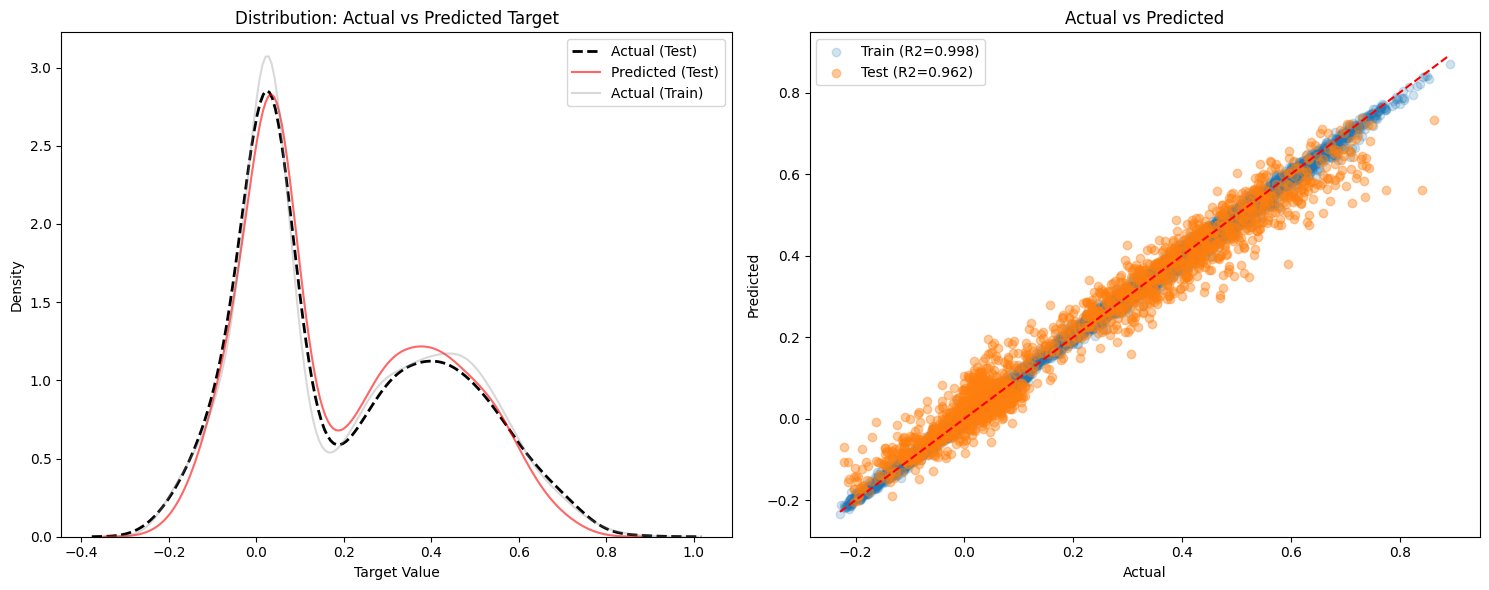

In [186]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from catboost import CatBoostRegressor

# 1. SETTINGS & OPTIMIZED PARAMETERS
FILE_DATA = "dataset_7.csv"
FILE_TARGET = "target_7.csv"

TOP_MI = ['feat_112','feat_143','feat_29','feat_240','feat_219','feat_179','feat_259']

BEST_PARAMS = {
    'fs_quantile': 0.9576647812118337,
    'pca_components': 26,
    'iterations': 2339,
    'depth': 9,
    'learning_rate': 0.04074858721679824,
    'l2_leaf_reg': 5.510871238071969,
    'bagging_temperature': 0.7183411444287063,
    'random_strength': 1.6049765464848271,
    'border_count': 254,
    'bootstrap_type': 'Bayesian',
    'random_state': 42,
    'verbose': 0
}

# 2. HELPER FUNCTIONS
def feature_engineering(X):
    X = X.copy()
    for i, f1 in enumerate(TOP_MI):
        X[f"{f1}_sq"] = X[f1] ** 2
        for f2 in TOP_MI[i+1:]:
            X[f"{f1}_{f2}"] = X[f1] * X[f2]
    return X

def calculate_metrics(y_true, y_pred, label):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"--- {label} Metrics ---")
    print(f"R2:   {r2:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}\n")
    return {"r2": r2, "rmse": rmse, "mae": mae}

# 3. DATA PREPARATION
X_raw = pd.read_csv(FILE_DATA)
y_raw = pd.read_csv(FILE_TARGET)["target01"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

# Feature Engineering
X_train_eng = feature_engineering(X_train_raw)
X_test_eng = feature_engineering(X_test_raw)

# PCA
pca = PCA(n_components=BEST_PARAMS['pca_components'], random_state=42)
pca_cols = [f"pca_{i}" for i in range(BEST_PARAMS['pca_components'])]

X_train_eng[pca_cols] = pca.fit_transform(X_train_eng.filter(regex="feat_"))
X_test_eng[pca_cols] = pca.transform(X_test_eng.filter(regex="feat_"))

# Feature Selection (Pilot)
pilot = CatBoostRegressor(iterations=100, depth=6, verbose=0, random_state=42)
pilot.fit(X_train_eng, y_train)

imp = pd.Series(pilot.get_feature_importance(), index=X_train_eng.columns)
selected_features = imp[imp >= imp.quantile(BEST_PARAMS['fs_quantile'])].index.tolist()

X_train_final = X_train_eng[selected_features]
X_test_final = X_test_eng[selected_features]

# 4. FINAL TRAINING (NO TARGET TRANSFORM)
print(f"Training final model with {len(selected_features)} features...")

model = CatBoostRegressor(
    iterations=BEST_PARAMS['iterations'],
    depth=BEST_PARAMS['depth'],
    learning_rate=BEST_PARAMS['learning_rate'],
    l2_leaf_reg=BEST_PARAMS['l2_leaf_reg'],
    bagging_temperature=BEST_PARAMS['bagging_temperature'],
    random_strength=BEST_PARAMS['random_strength'],
    border_count=BEST_PARAMS['border_count'],
    bootstrap_type=BEST_PARAMS['bootstrap_type'],
    random_state=42,
    verbose=0
)

model.fit(X_train_final, y_train)

# 5. PREDICTIONS
train_preds = model.predict(X_train_final)
test_preds = model.predict(X_test_final)

# 6. EVALUATION
metrics_train = calculate_metrics(y_train, train_preds, "TRAIN")
metrics_test = calculate_metrics(y_test, test_preds, "TEST")

# 7. VISUALIZATION
plt.figure(figsize=(15, 6))

# Distribution Plot
plt.subplot(1, 2, 1)
sns.kdeplot(y_test, label="Actual (Test)", color="black", linewidth=2, linestyle="--")
sns.kdeplot(test_preds, label="Predicted (Test)", color="red", alpha=0.6)
sns.kdeplot(y_train, label="Actual (Train)", color="gray", alpha=0.3)
plt.title("Distribution: Actual vs Predicted Target")
plt.xlabel("Target Value")
plt.legend()

# Scatter Plot
plt.subplot(1, 2, 2)
plt.scatter(y_train, train_preds, alpha=0.2, label=f"Train (R2={metrics_train['r2']:.3f})")
plt.scatter(y_test, test_preds, alpha=0.4, label=f"Test (R2={metrics_test['r2']:.3f})")
plt.plot([y_raw.min(), y_raw.max()], [y_raw.min(), y_raw.max()], 'r--')
plt.title("Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()

plt.tight_layout()
plt.show()


# 5 Fold

Starting 5-Fold Cross-Validation with Full Metrics...

Fold 1 | Train R2: 0.9958 | Test R2: 0.9672
Fold 2 | Train R2: 0.9948 | Test R2: 0.9647
Fold 3 | Train R2: 0.9953 | Test R2: 0.9642
Fold 4 | Train R2: 0.9961 | Test R2: 0.9634
Fold 5 | Train R2: 0.9955 | Test R2: 0.9658

--- FINAL CV METRICS (AVERAGED) ---
TRAIN -> R2: 0.9955 | RMSE: 0.0159 | MAE: 0.0116
TEST  -> R2: 0.9651 | RMSE: 0.0442 | MAE: 0.0318
Robust Features (All Folds): 8


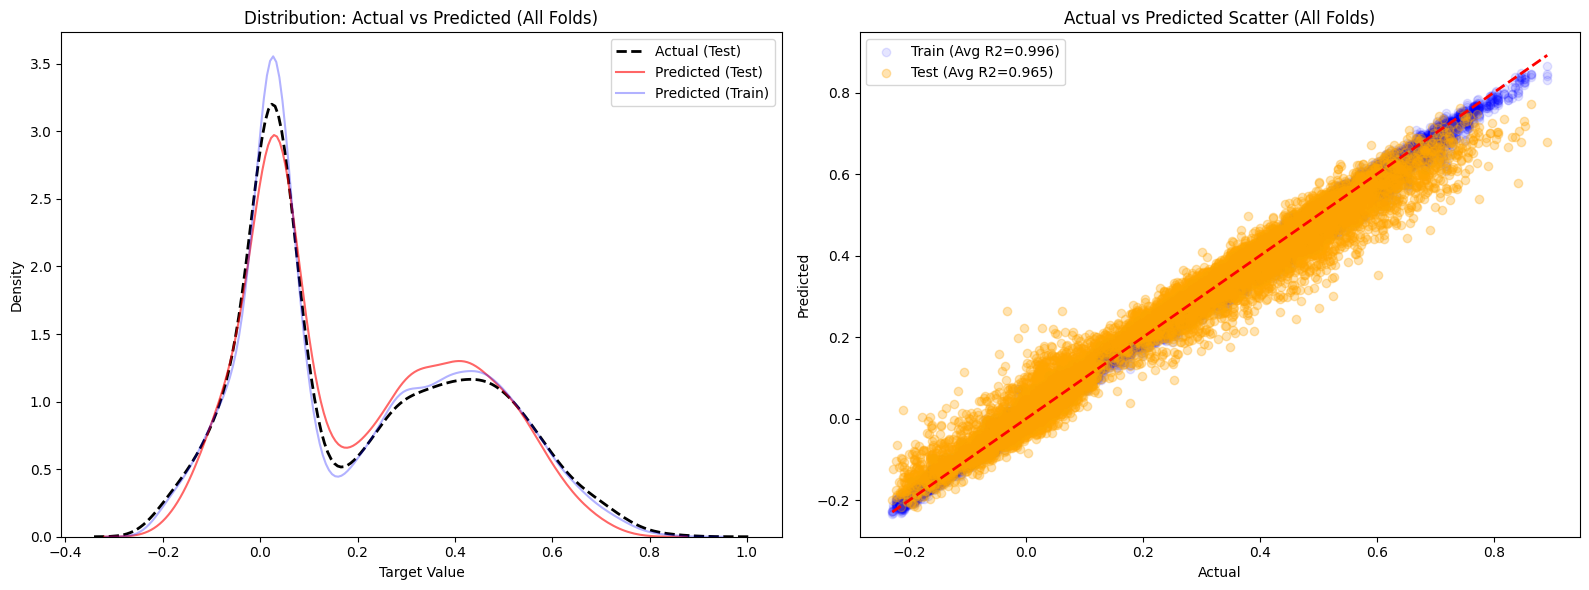

In [193]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from catboost import CatBoostRegressor

# 1. SETTINGS & OPTIMIZED PARAMETERS
FILE_DATA = "Dataset_7.csv"
FILE_TARGET = "target_7.csv"
TOP_MI = ['feat_112','feat_143','feat_29','feat_240','feat_219','feat_179','feat_259']

BEST_PARAMS = {
    'fs_quantile': 0.9576647812118337,
    'pca_components': 26,
    'iterations': 2339,
    'depth': 9,
    'learning_rate': 0.04074858721679824,
    # 'l2_leaf_reg': 5.510871238071969,
    'l2_leaf_reg': 20,
    'bagging_temperature': 0.7183411444287063,
    'random_strength': 1.6049765464848271,
    'border_count': 254,
    'bootstrap_type': 'Bayesian',
    'random_state': 42,
    'verbose': 0
}

# 2. HELPER FUNCTIONS
def feature_engineering(X):
    X = X.copy()
    for i, f1 in enumerate(TOP_MI):
        X[f"{f1}_sq"] = X[f1] ** 2
        for f2 in TOP_MI[i+1:]:
            X[f"{f1}_{f2}"] = X[f1] * X[f2]
    return X

def get_metrics(y_true, y_pred):
    return {
        'r2': r2_score(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'mae': mean_absolute_error(y_true, y_pred)
    }

# 3. DATA LOADING
X_raw = pd.read_csv(FILE_DATA)
y_raw = pd.read_csv(FILE_TARGET)["target01"]

# 4. CROSS-VALIDATION PIPELINE
kf = KFold(n_splits=5, shuffle=True, random_state=42)
train_metrics_list = []
test_metrics_list = []
all_selected_features = []

# Arrays to store all predictions for the final distribution/scatter plots
all_y_test = []
all_test_preds = []
all_y_train = []
all_train_preds = []

print(f"Starting 5-Fold Cross-Validation with Full Metrics...\n")

for fold, (train_idx, val_idx) in enumerate(kf.split(X_raw, y_raw)):
    X_train_fold, X_val_fold = X_raw.iloc[train_idx], X_raw.iloc[val_idx]
    y_train_fold, y_val_fold = y_raw.iloc[train_idx], y_raw.iloc[val_idx]
    
    # Feature Engineering
    X_train_eng = feature_engineering(X_train_fold)
    X_val_eng = feature_engineering(X_val_fold)
    
    # PCA (Strictly fit on train only)
    pca = PCA(n_components=BEST_PARAMS['pca_components'], random_state=42)
    pca_cols = [f"pca_{i}" for i in range(BEST_PARAMS['pca_components'])]
    X_train_eng[pca_cols] = pca.fit_transform(X_train_eng.filter(regex="feat_"))
    X_val_eng[pca_cols] = pca.transform(X_val_eng.filter(regex="feat_"))
    
    # Feature Selection Pilot
    pilot = CatBoostRegressor(iterations=100, depth=6, verbose=0, random_state=42)
    pilot.fit(X_train_eng, y_train_fold)
    imp = pd.Series(pilot.get_feature_importance(), index=X_train_eng.columns)
    selected_features = imp[imp >= imp.quantile(BEST_PARAMS['fs_quantile'])].index.tolist()
    all_selected_features.append(set(selected_features))
    
    # Final Model Training
    model = CatBoostRegressor(**{k: v for k, v in BEST_PARAMS.items() if k not in ['fs_quantile', 'pca_components']})
    model.fit(X_train_eng[selected_features], y_train_fold)
    
    # Predictions
    fold_train_preds = model.predict(X_train_eng[selected_features])
    fold_test_preds = model.predict(X_val_eng[selected_features])
    
    # Metrics
    train_m = get_metrics(y_train_fold, fold_train_preds)
    test_m = get_metrics(y_val_fold, fold_test_preds)
    
    train_metrics_list.append(train_m)
    test_metrics_list.append(test_m)
    
    # Store for visualization
    all_y_test.extend(y_val_fold)
    all_test_preds.extend(fold_test_preds)
    all_y_train.extend(y_train_fold)
    all_train_preds.extend(fold_train_preds)
    
    print(f"Fold {fold+1} | Train R2: {train_m['r2']:.4f} | Test R2: {test_m['r2']:.4f}")

# 5. AGGREGATE RESULTS
avg_train_r2 = np.mean([m['r2'] for m in train_metrics_list])
avg_test_r2 = np.mean([m['r2'] for m in test_metrics_list])
common_feats = set.intersection(*all_selected_features)

print(f"\n--- FINAL CV METRICS (AVERAGED) ---")
print(f"TRAIN -> R2: {avg_train_r2:.4f} | RMSE: {np.mean([m['rmse'] for m in train_metrics_list]):.4f} | MAE: {np.mean([m['mae'] for m in train_metrics_list]):.4f}")
print(f"TEST  -> R2: {avg_test_r2:.4f} | RMSE: {np.mean([m['rmse'] for m in test_metrics_list]):.4f} | MAE: {np.mean([m['mae'] for m in test_metrics_list]):.4f}")
print(f"Robust Features (All Folds): {len(common_feats)}")

# 6. ENHANCED VISUALIZATION
plt.figure(figsize=(16, 6))

# Subplot 1: Distribution Plot
plt.subplot(1, 2, 1)
sns.kdeplot(all_y_test, label="Actual (Test)", color="black", linewidth=2, linestyle="--")
sns.kdeplot(all_test_preds, label="Predicted (Test)", color="red", alpha=0.6)
sns.kdeplot(all_train_preds, label="Predicted (Train)", color="blue", alpha=0.3)
plt.title("Distribution: Actual vs Predicted (All Folds)")
plt.xlabel("Target Value")
plt.legend()

# Subplot 2: Scatter Plot
plt.subplot(1, 2, 2)
plt.scatter(all_y_train, all_train_preds, alpha=0.1, color='blue', label=f"Train (Avg R2={avg_train_r2:.3f})")
plt.scatter(all_y_test, all_test_preds, alpha=0.3, color='orange', label=f"Test (Avg R2={avg_test_r2:.3f})")
plt.plot([y_raw.min(), y_raw.max()], [y_raw.min(), y_raw.max()], 'r--', lw=2)
plt.title("Actual vs Predicted Scatter (All Folds)")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()

plt.tight_layout()
plt.show()

Loading and preparing final training model...
Final model trained on 14 features.
Loading EVAL_7.csv and generating predictions...


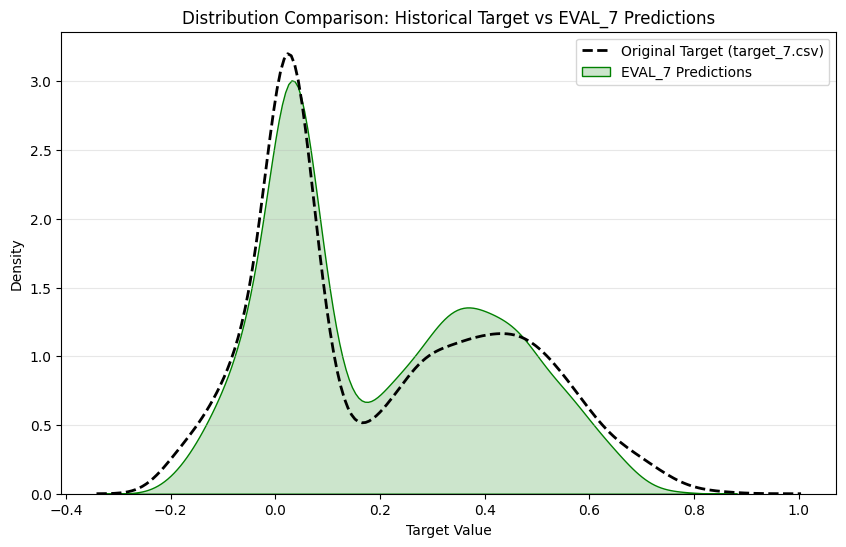

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from catboost import CatBoostRegressor

# 1. SETTINGS
FILE_DATA = "Dataset_7.csv"
FILE_TARGET = "target_7.csv"
FILE_EVAL = "EVAL_7.csv"  # The new data
TOP_MI = ['feat_112','feat_143','feat_29','feat_240','feat_219','feat_179','feat_259']

BEST_PARAMS = {
    'fs_quantile': 0.9576647812118337,
    'pca_components': 26,
    'iterations': 2339,
    'depth': 9,
    'learning_rate': 0.04074858721679824,
    'l2_leaf_reg': 5.510871238071969,
    'bagging_temperature': 0.7183411444287063,
    'random_strength': 1.6049765464848271,
    'border_count': 254,
    'bootstrap_type': 'Bayesian',
    'random_state': 42,
    'verbose': 0
}

def feature_engineering(X):
    X = X.copy()
    for i, f1 in enumerate(TOP_MI):
        X[f"{f1}_sq"] = X[f1] ** 2
        for f2 in TOP_MI[i+1:]:
            X[f"{f1}_{f2}"] = X[f1] * X[f2]
    return X

# 2. FINAL TRAINING (To "finalize" the model for prediction)
print("Loading and preparing final training model...")
X_train_raw = pd.read_csv(FILE_DATA)
y_train = pd.read_csv(FILE_TARGET)["target01"]

X_train_eng = feature_engineering(X_train_raw)
pca = PCA(n_components=BEST_PARAMS['pca_components'], random_state=42)
pca_cols = [f"pca_{i}" for i in range(BEST_PARAMS['pca_components'])]
X_train_eng[pca_cols] = pca.fit_transform(X_train_eng.filter(regex="feat_"))

# Feature Selection (Sovereign run to get the best features)
pilot = CatBoostRegressor(iterations=100, depth=6, verbose=0, random_state=42)
pilot.fit(X_train_eng, y_train)
imp = pd.Series(pilot.get_feature_importance(), index=X_train_eng.columns)
selected_features = imp[imp >= imp.quantile(BEST_PARAMS['fs_quantile'])].index.tolist()

final_model = CatBoostRegressor(**{k: v for k, v in BEST_PARAMS.items() if k not in ['fs_quantile', 'pca_components']})
final_model.fit(X_train_eng[selected_features], y_train)
print(f"Final model trained on {len(selected_features)} features.")

# 3. PREDICTIONS ON EVAL_7
print(f"Loading {FILE_EVAL} and generating predictions...")
X_eval_raw = pd.read_csv(FILE_EVAL)
X_eval_eng = feature_engineering(X_eval_raw)
X_eval_eng[pca_cols] = pca.transform(X_eval_eng.filter(regex="feat_"))
X_eval_final = X_eval_eng[selected_features]

eval_predictions = final_model.predict(X_eval_final)

# 4. VISUALIZATION
plt.figure(figsize=(10, 6))

# Plotting the target distribution from the training set vs evaluation predictions
sns.kdeplot(y_train, label="Original Target (target_7.csv)", color="black", linewidth=2, linestyle="--")
sns.kdeplot(eval_predictions, label="EVAL_7 Predictions", color="green", fill=True, alpha=0.2)

plt.title("Distribution Comparison: Historical Target vs EVAL_7 Predictions")
plt.xlabel("Target Value")
plt.ylabel("Density")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Optional: Save predictions
# pd.DataFrame(eval_predictions, columns=['predicted_target']).to_csv("eval_7_preds.csv", index=False)

# Again but afyter fixing the leakage again

Starting 5-Fold Cross-Validation...

Fold 1 | Train R2: 0.9921 | Test R2: 0.9625
Fold 2 | Train R2: 0.9909 | Test R2: 0.9558
Fold 3 | Train R2: 0.9902 | Test R2: 0.9526
Fold 4 | Train R2: 0.9929 | Test R2: 0.9629
Fold 5 | Train R2: 0.9920 | Test R2: 0.9601

--- FINAL CV METRICS ---
TRAIN R2: 0.9916 | TEST R2: 0.9588
Robust Features found in all folds: 8


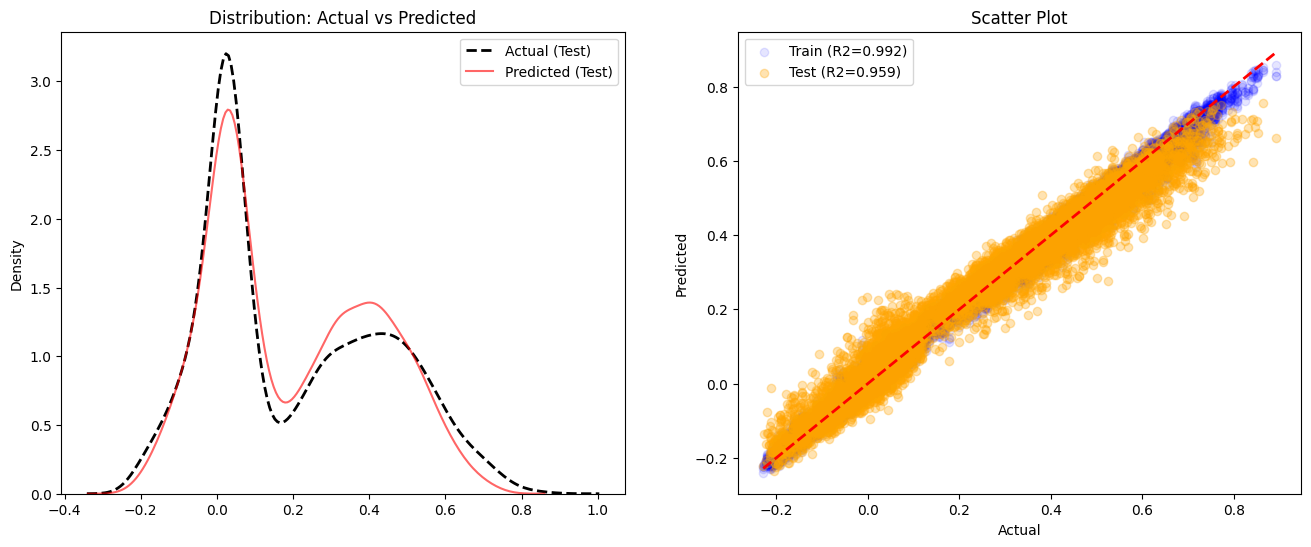

Model saved with 14 features in specific order.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from catboost import CatBoostRegressor

# 1. SETTINGS & OPTIMIZED PARAMETERS
FILE_DATA = "Dataset_7.csv"
FILE_TARGET = "target_7.csv"
TOP_MI = ['feat_112','feat_143','feat_29','feat_240','feat_219','feat_179','feat_259']

BEST_PARAMS = {
    'fs_quantile': 0.9576647812118337,
    'pca_components': 26,
    # 'iterations': 2339,
    'iterations': 1500,
    'depth': 8,
    'learning_rate': 0.04074858721679824,
    'l2_leaf_reg': 5.510871238071969,
    'bagging_temperature': 0.7183411444287063,
    'random_strength': 1.6049765464848271,
    'border_count': 254,
    'bootstrap_type': 'Bayesian',
    'random_state': 42,
    'verbose': 0
}

# 2. HELPER FUNCTIONS
def feature_engineering(X):
    X = X.copy()
    for i, f1 in enumerate(TOP_MI):
        X[f"{f1}_sq"] = X[f1] ** 2
        for f2 in TOP_MI[i+1:]:
            X[f"{f1}_{f2}"] = X[f1] * X[f2]
    return X

def get_metrics(y_true, y_pred):
    return {
        'r2': r2_score(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'mae': mean_absolute_error(y_true, y_pred)
    }

# 3. DATA LOADING
X_raw = pd.read_csv(FILE_DATA)
y_raw = pd.read_csv(FILE_TARGET)["target01"]

# 4. CROSS-VALIDATION PIPELINE
kf = KFold(n_splits=5, shuffle=True, random_state=42)
train_metrics_list = []
test_metrics_list = []
all_selected_features = []

all_y_test, all_test_preds = [], []
all_y_train, all_train_preds = [], []

print(f"Starting 5-Fold Cross-Validation...\n")

for fold, (train_idx, val_idx) in enumerate(kf.split(X_raw, y_raw)):
    # Split
    X_train_fold, X_val_fold = X_raw.iloc[train_idx].copy(), X_raw.iloc[val_idx].copy()
    y_train_fold, y_val_fold = y_raw.iloc[train_idx], y_raw.iloc[val_idx]
    
    # 4a. Feature Engineering (Interaction terms)
    X_train_eng = feature_engineering(X_train_fold)
    X_val_eng = feature_engineering(X_val_fold)
    
    # 4b. PCA (Strict Fit-Transform Discipline)
    pca = PCA(n_components=BEST_PARAMS['pca_components'], random_state=42)
    feat_cols = [c for c in X_train_eng.columns if "feat_" in c]
    
    pca_train = pca.fit_transform(X_train_eng[feat_cols])
    pca_val = pca.transform(X_val_eng[feat_cols])
    
    pca_cols = [f"pca_{i}" for i in range(BEST_PARAMS['pca_components'])]
    X_train_eng[pca_cols] = pca_train
    X_val_eng[pca_cols] = pca_val
    
    # 4c. Feature Selection Pilot (Dynamic per fold)
    pilot = CatBoostRegressor(iterations=100, depth=6, verbose=0, random_state=42)
    pilot.fit(X_train_eng, y_train_fold)
    
    imp = pd.Series(pilot.get_feature_importance(), index=X_train_eng.columns)
    # Using the pre-tuned quantile to select features based ONLY on this fold's importance
    thresh = imp.quantile(BEST_PARAMS['fs_quantile'])
    selected_features = imp[imp >= thresh].index.tolist()
    all_selected_features.append(set(selected_features))
    
    # 4d. Final Model Training
    model_params = {k: v for k, v in BEST_PARAMS.items() if k not in ['fs_quantile', 'pca_components']}
    model = CatBoostRegressor(**model_params)
    model.fit(X_train_eng[selected_features], y_train_fold)
    
    # 4e. Predictions & Metrics
    f_train_preds = model.predict(X_train_eng[selected_features])
    f_test_preds = model.predict(X_val_eng[selected_features])
    
    train_m = get_metrics(y_train_fold, f_train_preds)
    test_m = get_metrics(y_val_fold, f_test_preds)
    
    train_metrics_list.append(train_m)
    test_metrics_list.append(test_m)
    
    all_y_test.extend(y_val_fold)
    all_test_preds.extend(f_test_preds)
    all_y_train.extend(y_train_fold)
    all_train_preds.extend(f_train_preds)
    
    print(f"Fold {fold+1} | Train R2: {train_m['r2']:.4f} | Test R2: {test_m['r2']:.4f}")

# 5. AGGREGATE RESULTS
avg_train_r2 = np.mean([m['r2'] for m in train_metrics_list])
avg_test_r2 = np.mean([m['r2'] for m in test_metrics_list])
common_feats = set.intersection(*all_selected_features)

print(f"\n--- FINAL CV METRICS ---")
print(f"TRAIN R2: {avg_train_r2:.4f} | TEST R2: {avg_test_r2:.4f}")
print(f"Robust Features found in all folds: {len(common_feats)}")

# 6. VISUALIZATION
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.kdeplot(all_y_test, label="Actual (Test)", color="black", lw=2, ls="--")
sns.kdeplot(all_test_preds, label="Predicted (Test)", color="red", alpha=0.6)
plt.title("Distribution: Actual vs Predicted")
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(all_y_train, all_train_preds, alpha=0.1, color='blue', label=f"Train (R2={avg_train_r2:.3f})")
plt.scatter(all_y_test, all_test_preds, alpha=0.3, color='orange', label=f"Test (R2={avg_test_r2:.3f})")
plt.plot([y_raw.min(), y_raw.max()], [y_raw.min(), y_raw.max()], 'r--', lw=2)
plt.xlabel("Actual"); plt.ylabel("Predicted"); plt.title("Scatter Plot")
plt.legend()
plt.show()


Loading and preparing final training model...
Final model trained on 14 features.
Loading EVAL_7.csv and generating predictions...


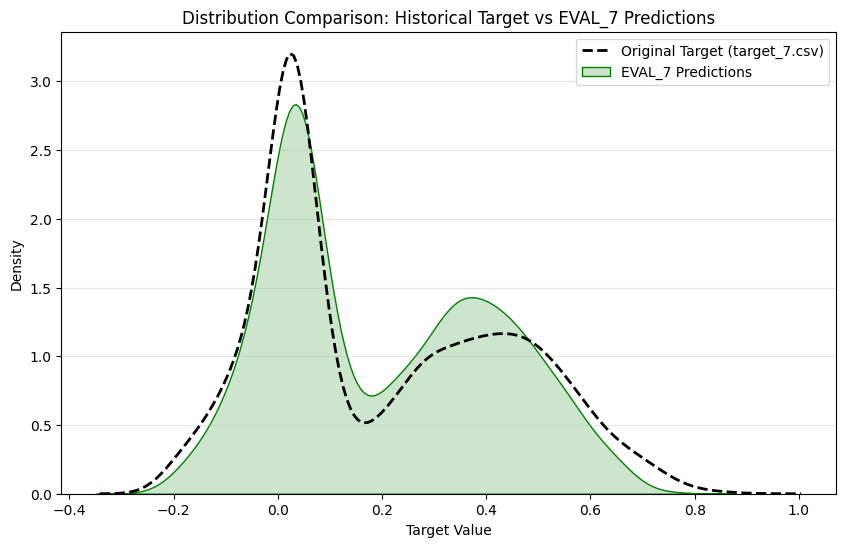

In [208]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from catboost import CatBoostRegressor

# 1. SETTINGS
FILE_DATA = "Dataset_7.csv"
FILE_TARGET = "target_7.csv"
FILE_EVAL = "EVAL_7.csv"  # The new data
TOP_MI = ['feat_112','feat_143','feat_29','feat_240','feat_219','feat_179','feat_259']

BEST_PARAMS = {
    'fs_quantile': 0.9576647812118337,
    'pca_components': 26,
    'iterations': 1500,
    'depth': 8,
    'learning_rate': 0.04074858721679824,
    'l2_leaf_reg': 5.510871238071969,
    'bagging_temperature': 0.7183411444287063,
    'random_strength': 1.6049765464848271,
    'border_count': 254,
    'bootstrap_type': 'Bayesian',
    'random_state': 42,
    'verbose': 0
}

def feature_engineering(X):
    X = X.copy()
    for i, f1 in enumerate(TOP_MI):
        X[f"{f1}_sq"] = X[f1] ** 2
        for f2 in TOP_MI[i+1:]:
            X[f"{f1}_{f2}"] = X[f1] * X[f2]
    return X

# 2. FINAL TRAINING (To "finalize" the model for prediction)
print("Loading and preparing final training model...")
X_train_raw = pd.read_csv(FILE_DATA)
y_train = pd.read_csv(FILE_TARGET)["target01"]

X_train_eng = feature_engineering(X_train_raw)
pca = PCA(n_components=BEST_PARAMS['pca_components'], random_state=42)
pca_cols = [f"pca_{i}" for i in range(BEST_PARAMS['pca_components'])]
X_train_eng[pca_cols] = pca.fit_transform(X_train_eng.filter(regex="feat_"))

# Feature Selection (Sovereign run to get the best features)
pilot = CatBoostRegressor(iterations=100, depth=6, verbose=0, random_state=42)
pilot.fit(X_train_eng, y_train)
imp = pd.Series(pilot.get_feature_importance(), index=X_train_eng.columns)
selected_features = imp[imp >= imp.quantile(BEST_PARAMS['fs_quantile'])].index.tolist()

final_model = CatBoostRegressor(**{k: v for k, v in BEST_PARAMS.items() if k not in ['fs_quantile', 'pca_components']})
final_model.fit(X_train_eng[selected_features], y_train)
print(f"Final model trained on {len(selected_features)} features.")

# 3. PREDICTIONS ON EVAL_7
print(f"Loading {FILE_EVAL} and generating predictions...")
X_eval_raw = pd.read_csv(FILE_EVAL)
X_eval_eng = feature_engineering(X_eval_raw)
X_eval_eng[pca_cols] = pca.transform(X_eval_eng.filter(regex="feat_"))
X_eval_final = X_eval_eng[selected_features]

eval_predictions = final_model.predict(X_eval_final)

# 4. VISUALIZATION
plt.figure(figsize=(10, 6))

# Plotting the target distribution from the training set vs evaluation predictions
sns.kdeplot(y_train, label="Original Target (target_7.csv)", color="black", linewidth=2, linestyle="--")
sns.kdeplot(eval_predictions, label="EVAL_7 Predictions", color="green", fill=True, alpha=0.2)

plt.title("Distribution Comparison: Historical Target vs EVAL_7 Predictions")
plt.xlabel("Target Value")
plt.ylabel("Density")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Optional: Save predictions
# pd.DataFrame(eval_predictions, columns=['predicted_target']).to_csv("eval_7_preds.csv", index=False)

# Whole Pipeline

Starting 5-Fold Cross-Validation & Eval Preparation...

Fold 1 | Train R2: 0.9921 | Test R2: 0.9625
Fold 2 | Train R2: 0.9909 | Test R2: 0.9558
Fold 3 | Train R2: 0.9902 | Test R2: 0.9526
Fold 4 | Train R2: 0.9929 | Test R2: 0.9629
Fold 5 | Train R2: 0.9920 | Test R2: 0.9601

--- FINAL CV METRICS ---
TRAIN -> R2: 0.9916 | RMSE: 0.0216 | MAE: 0.0162
TEST  -> R2: 0.9588 | RMSE: 0.0480 | MAE: 0.0356


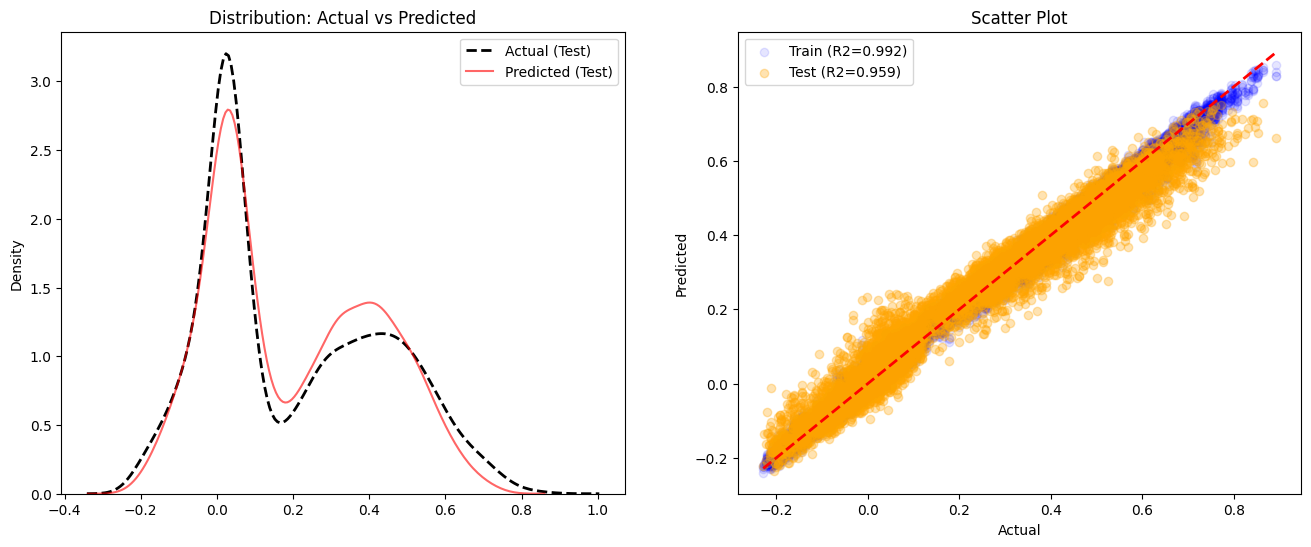


Generating predictions for EVAL_7.csv...
Results saved to EVAL_target01_7.csv


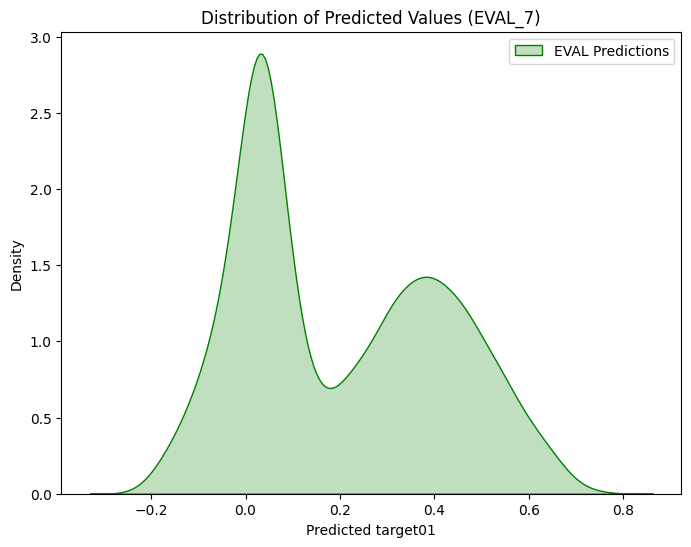

In [211]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from catboost import CatBoostRegressor

# 1. SETTINGS & OPTIMIZED PARAMETERS
FILE_DATA = "Dataset_7.csv"
FILE_TARGET = "target_7.csv"
FILE_EVAL = "EVAL_7.csv"
TOP_MI = ['feat_112','feat_143','feat_29','feat_240','feat_219','feat_179','feat_259']

BEST_PARAMS = {
    'fs_quantile': 0.9576647812118337,
    'pca_components': 26,
    'iterations': 1500,
    'depth': 8,
    'learning_rate': 0.04074858721679824,
    'l2_leaf_reg': 5.510871238071969,
    'bagging_temperature': 0.7183411444287063,
    'random_strength': 1.6049765464848271,
    'border_count': 254,
    'bootstrap_type': 'Bayesian',
    'random_state': 42,
    'verbose': 0
}

# 2. HELPER FUNCTIONS
def feature_engineering(X):
    X = X.copy()
    for i, f1 in enumerate(TOP_MI):
        X[f"{f1}_sq"] = X[f1] ** 2
        for f2 in TOP_MI[i+1:]:
            X[f"{f1}_{f2}"] = X[f1] * X[f2]
    return X

def get_metrics(y_true, y_pred):
    return {
        'r2': r2_score(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'mae': mean_absolute_error(y_true, y_pred)
    }

# 3. DATA LOADING
X_raw = pd.read_csv(FILE_DATA)
y_raw = pd.read_csv(FILE_TARGET)["target01"]
X_eval_raw = pd.read_csv(FILE_EVAL)

# 4. CROSS-VALIDATION PIPELINE
kf = KFold(n_splits=5, shuffle=True, random_state=42)
train_metrics_list = []
test_metrics_list = []

all_y_test, all_test_preds = [], []
fold_models = [] # To store models and their specific features for Eval

print(f"Starting 5-Fold Cross-Validation & Eval Preparation...\n")

for fold, (train_idx, val_idx) in enumerate(kf.split(X_raw, y_raw)):
    X_train_fold, X_val_fold = X_raw.iloc[train_idx].copy(), X_raw.iloc[val_idx].copy()
    y_train_fold, y_val_fold = y_raw.iloc[train_idx], y_raw.iloc[val_idx]
    
    # 4a. Feature Engineering
    X_train_eng = feature_engineering(X_train_fold)
    X_val_eng = feature_engineering(X_val_fold)
    
    # 4b. PCA
    pca = PCA(n_components=BEST_PARAMS['pca_components'], random_state=42)
    feat_cols = [c for c in X_train_eng.columns if "feat_" in c]
    
    pca_train = pca.fit_transform(X_train_eng[feat_cols])
    pca_val = pca.transform(X_val_eng[feat_cols])
    
    pca_cols = [f"pca_{i}" for i in range(BEST_PARAMS['pca_components'])]
    X_train_eng[pca_cols] = pca_train
    X_val_eng[pca_cols] = pca_val
    
    # 4c. Feature Selection Pilot
    pilot = CatBoostRegressor(iterations=100, depth=6, verbose=0, random_state=42)
    pilot.fit(X_train_eng, y_train_fold)
    
    imp = pd.Series(pilot.get_feature_importance(), index=X_train_eng.columns)
    thresh = imp.quantile(BEST_PARAMS['fs_quantile'])
    selected_features = imp[imp >= thresh].index.tolist()
    
    # 4d. Final Model Training
    model_params = {k: v for k, v in BEST_PARAMS.items() if k not in ['fs_quantile', 'pca_components']}
    model = CatBoostRegressor(**model_params)
    model.fit(X_train_eng[selected_features], y_train_fold)
    
    # Save for Inference
    fold_models.append({
        'model': model,
        'pca': pca,
        'features': selected_features,
        'feat_cols': feat_cols # Original cols used for PCA
    })
    
    # 4e. Predictions & Metrics
    f_train_preds = model.predict(X_train_eng[selected_features])
    f_test_preds = model.predict(X_val_eng[selected_features])
    
    train_m = get_metrics(y_train_fold, f_train_preds)
    test_m = get_metrics(y_val_fold, f_test_preds)
    
    train_metrics_list.append(train_m)
    test_metrics_list.append(test_m)
    all_y_test.extend(y_val_fold)
    all_test_preds.extend(f_test_preds)
    
    print(f"Fold {fold+1} | Train R2: {train_m['r2']:.4f} | Test R2: {test_m['r2']:.4f}")

# # 5. AGGREGATE CV RESULTS
# avg_test_r2 = np.mean([m['r2'] for m in test_metrics_list])
# print(f"\n--- FINAL CV METRICS ---")
# print(f"AVG TEST R2: {avg_test_r2:.4f}")

# 5. AGGREGATE RESULTS (Expanded Metrics)
avg_test_r2 = np.mean([m['r2'] for m in test_metrics_list])
avg_test_rmse = np.mean([m['rmse'] for m in test_metrics_list])
avg_test_mae = np.mean([m['mae'] for m in test_metrics_list])

avg_train_r2 = np.mean([m['r2'] for m in train_metrics_list])
avg_train_rmse = np.mean([m['rmse'] for m in train_metrics_list])
avg_train_mae = np.mean([m['mae'] for m in train_metrics_list])

print(f"\n--- FINAL CV METRICS ---")
print(f"TRAIN -> R2: {avg_train_r2:.4f} | RMSE: {avg_train_rmse:.4f} | MAE: {avg_train_mae:.4f}")
print(f"TEST  -> R2: {avg_test_r2:.4f} | RMSE: {avg_test_rmse:.4f} | MAE: {avg_test_mae:.4f}")

# 5.5 VISUALIZATION
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.kdeplot(all_y_test, label="Actual (Test)", color="black", lw=2, ls="--")
sns.kdeplot(all_test_preds, label="Predicted (Test)", color="red", alpha=0.6)
plt.title("Distribution: Actual vs Predicted")
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(all_y_train, all_train_preds, alpha=0.1, color='blue', label=f"Train (R2={avg_train_r2:.3f})")
plt.scatter(all_y_test, all_test_preds, alpha=0.3, color='orange', label=f"Test (R2={avg_test_r2:.3f})")
plt.plot([y_raw.min(), y_raw.max()], [y_raw.min(), y_raw.max()], 'r--', lw=2)
plt.xlabel("Actual"); plt.ylabel("Predicted"); plt.title("Scatter Plot")
plt.legend()
plt.show()

# 6. EVALUATION PREDICTIONS (Handling potential mismatch)
print(f"\nGenerating predictions for {FILE_EVAL}...")
eval_preds_accumulated = np.zeros(len(X_eval_raw))

for i, fold_pack in enumerate(fold_models):
    # Apply Feature Engineering
    X_eval_eng = feature_engineering(X_eval_raw)
    
    # Apply PCA using the specific fit from this fold
    pca_eval = fold_pack['pca'].transform(X_eval_eng[fold_pack['feat_cols']])
    pca_cols = [f"pca_{j}" for j in range(BEST_PARAMS['pca_components'])]
    X_eval_eng[pca_cols] = pca_eval
    
    # Predict using the features selected in this fold
    fold_eval_preds = fold_pack['model'].predict(X_eval_eng[fold_pack['features']])
    eval_preds_accumulated += fold_eval_preds

# Average the predictions across all 5 folds
final_eval_preds = eval_preds_accumulated / len(fold_models)

# 7. SAVE RESULTS
pd.DataFrame({'target01': final_eval_preds}).to_csv("EVAL_target01_7.csv", index=False)
print("Results saved to EVAL_target01_7.csv")

# 8. VISUALIZATION OF EVAL PREDICTIONS
plt.figure(figsize=(8, 6))
sns.kdeplot(final_eval_preds, color="green", fill=True, label="EVAL Predictions")
plt.title("Distribution of Predicted Values (EVAL_7)")
plt.xlabel("Predicted target01")
plt.legend()
plt.show()

Starting 5-Fold Cross-Validation...

Fold 1 | Train R2: 0.9921 | Test R2: 0.9625
Fold 2 | Train R2: 0.9909 | Test R2: 0.9558
Fold 3 | Train R2: 0.9902 | Test R2: 0.9526
Fold 4 | Train R2: 0.9929 | Test R2: 0.9629
Fold 5 | Train R2: 0.9920 | Test R2: 0.9601

--- FINAL CV METRICS ---
TRAIN R2: 0.9916 | TEST R2: 0.9588
Robust Features found in all folds: 8


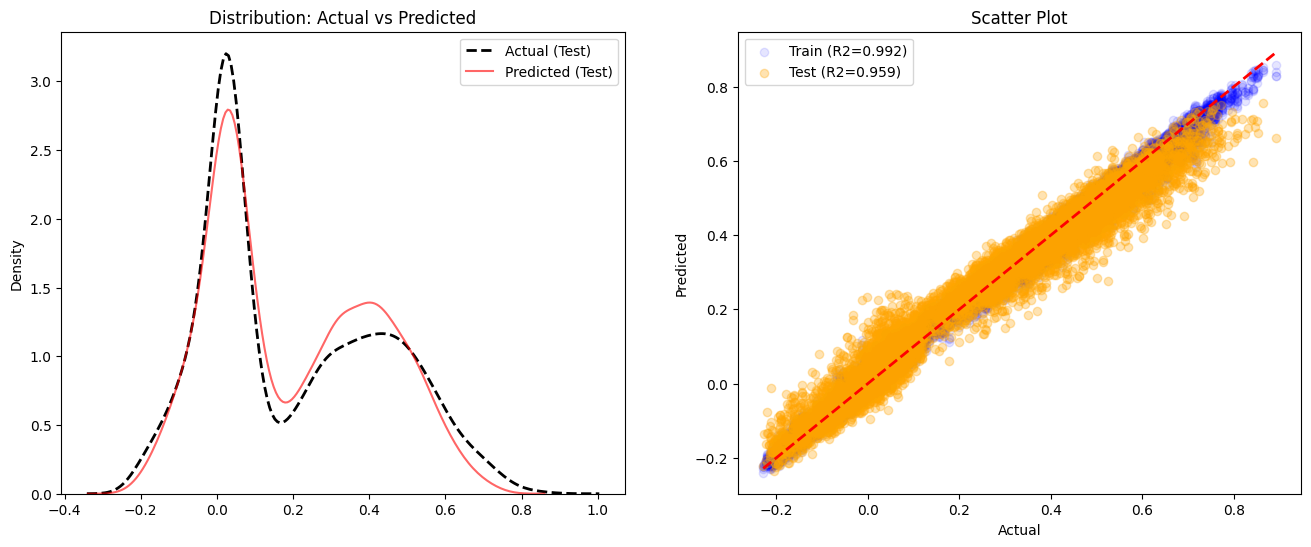

In [219]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from catboost import CatBoostRegressor

# 1. SETTINGS & OPTIMIZED PARAMETERS
FILE_DATA = "Dataset_7.csv"
FILE_TARGET = "target_7.csv"
TOP_MI = ['feat_112','feat_143','feat_29','feat_240','feat_219','feat_179','feat_259']

BEST_PARAMS = {
    'fs_quantile': 0.9576647812118337,
    'pca_components': 26,
    # 'iterations': 2339,
    'iterations': 1500,
    'depth': 8,
    'learning_rate': 0.04074858721679824,
    'l2_leaf_reg': 5.510871238071969,
    'bagging_temperature': 0.7183411444287063,
    'random_strength': 1.6049765464848271,
    'border_count': 254,
    'bootstrap_type': 'Bayesian',
    'random_state': 42,
    'verbose': 0,
    # **{k: v for k, v in BEST_PARAMS.items() if k not in ['fs_quantile', 'pca_components']},
    # 'leaf_estimation_method': 'Newton',   # needed for linear leaves
    # 'boosting_type': 'Plain',             # ensure Plain boosting
    # 'model_size_reg': 0.5,                # regularization for linear leaf coefficients
    # # 'use_best_model': False,              # optional
    # 'max_ctr_complexity': 2               # optional, keep feature interactions manageable
}

# 2. HELPER FUNCTIONS
def feature_engineering(X):
    X = X.copy()
    for i, f1 in enumerate(TOP_MI):
        X[f"{f1}_sq"] = X[f1] ** 2
        for f2 in TOP_MI[i+1:]:
            X[f"{f1}_{f2}"] = X[f1] * X[f2]
    return X

def get_metrics(y_true, y_pred):
    return {
        'r2': r2_score(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'mae': mean_absolute_error(y_true, y_pred)
    }

# 3. DATA LOADING
X_raw = pd.read_csv(FILE_DATA)
y_raw = pd.read_csv(FILE_TARGET)["target01"]

# 4. CROSS-VALIDATION PIPELINE
kf = KFold(n_splits=5, shuffle=True, random_state=42)
train_metrics_list = []
test_metrics_list = []
all_selected_features = []

all_y_test, all_test_preds = [], []
all_y_train, all_train_preds = [], []

print(f"Starting 5-Fold Cross-Validation...\n")

for fold, (train_idx, val_idx) in enumerate(kf.split(X_raw, y_raw)):
    # Split
    X_train_fold, X_val_fold = X_raw.iloc[train_idx].copy(), X_raw.iloc[val_idx].copy()
    y_train_fold, y_val_fold = y_raw.iloc[train_idx], y_raw.iloc[val_idx]
    
    # 4a. Feature Engineering (Interaction terms)
    X_train_eng = feature_engineering(X_train_fold)
    X_val_eng = feature_engineering(X_val_fold)
    
    # 4b. PCA (Strict Fit-Transform Discipline)
    pca = PCA(n_components=BEST_PARAMS['pca_components'], random_state=42)
    feat_cols = [c for c in X_train_eng.columns if "feat_" in c]
    
    pca_train = pca.fit_transform(X_train_eng[feat_cols])
    pca_val = pca.transform(X_val_eng[feat_cols])
    
    pca_cols = [f"pca_{i}" for i in range(BEST_PARAMS['pca_components'])]
    X_train_eng[pca_cols] = pca_train
    X_val_eng[pca_cols] = pca_val
    
    # 4c. Feature Selection Pilot (Dynamic per fold)
    pilot = CatBoostRegressor(iterations=100, depth=6, verbose=0, random_state=42)
    pilot.fit(X_train_eng, y_train_fold)
    
    imp = pd.Series(pilot.get_feature_importance(), index=X_train_eng.columns)
    # Using the pre-tuned quantile to select features based ONLY on this fold's importance
    thresh = imp.quantile(BEST_PARAMS['fs_quantile'])
    selected_features = imp[imp >= thresh].index.tolist()
    all_selected_features.append(set(selected_features))
    
    # 4d. Final Model Training
    model_params = {k: v for k, v in BEST_PARAMS.items() if k not in ['fs_quantile', 'pca_components']}
    model = CatBoostRegressor(**model_params)
    model.fit(X_train_eng[selected_features], y_train_fold)
    
    # 4e. Predictions & Metrics
    f_train_preds = model.predict(X_train_eng[selected_features])
    f_test_preds = model.predict(X_val_eng[selected_features])
    
    train_m = get_metrics(y_train_fold, f_train_preds)
    test_m = get_metrics(y_val_fold, f_test_preds)
    
    train_metrics_list.append(train_m)
    test_metrics_list.append(test_m)
    
    all_y_test.extend(y_val_fold)
    all_test_preds.extend(f_test_preds)
    all_y_train.extend(y_train_fold)
    all_train_preds.extend(f_train_preds)
    
    print(f"Fold {fold+1} | Train R2: {train_m['r2']:.4f} | Test R2: {test_m['r2']:.4f}")

# 5. AGGREGATE RESULTS
avg_train_r2 = np.mean([m['r2'] for m in train_metrics_list])
avg_test_r2 = np.mean([m['r2'] for m in test_metrics_list])
common_feats = set.intersection(*all_selected_features)

print(f"\n--- FINAL CV METRICS ---")
print(f"TRAIN R2: {avg_train_r2:.4f} | TEST R2: {avg_test_r2:.4f}")
print(f"Robust Features found in all folds: {len(common_feats)}")

# 6. VISUALIZATION
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.kdeplot(all_y_test, label="Actual (Test)", color="black", lw=2, ls="--")
sns.kdeplot(all_test_preds, label="Predicted (Test)", color="red", alpha=0.6)
plt.title("Distribution: Actual vs Predicted")
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(all_y_train, all_train_preds, alpha=0.1, color='blue', label=f"Train (R2={avg_train_r2:.3f})")
plt.scatter(all_y_test, all_test_preds, alpha=0.3, color='orange', label=f"Test (R2={avg_test_r2:.3f})")
plt.plot([y_raw.min(), y_raw.max()], [y_raw.min(), y_raw.max()], 'r--', lw=2)
plt.xlabel("Actual"); plt.ylabel("Predicted"); plt.title("Scatter Plot")
plt.legend()
plt.show()
